# 🏆 PatchTST với Fixed Parameters - Smooth Linear 20% + Post-processing

Notebook này sử dụng **các thông số Optuna đã được tối ưu** từ `patchtst_best_method.ipynb`:
- **Best Method**: Smooth Linear 20% + Post-processing (Linear Regression)
- **Fixed Parameters**: Sử dụng best parameters từ Optuna (không cần chạy Optuna lại)

## Thông số đã được cố định:
- `input_size`: 100
- `patch_len`: 32
- `stride`: 4
- `learning_rate`: 0.001610814898983045
- `max_steps`: 250

## Phương pháp:
1. **PatchTST** với fixed hyperparameters (đã tối ưu từ Optuna)
2. **Post-processing Regression** (Linear Regression) để điều chỉnh predictions
3. **Smooth Bias Correction** (Linear 20%):
   - Phần đầu (20%): Smooth transition (giữ nguyên giá trị đầu)
   - Phần cuối (80%): Post-processing Regression


## 1. Setup và Import Libraries


In [80]:
# Cài đặt các thư viện cần thiết
import subprocess
import sys

def install_package(package, import_name=None):
    """Cài đặt package nếu chưa có"""
    if import_name is None:
        import_name = package
    try:
        __import__(import_name)
        print(f"✓ {package} đã được cài đặt")
        return True
    except ImportError:
        print(f"📦 Đang cài đặt {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package],
                                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            print(f"✓ Đã cài đặt {package}")
            return True
        except Exception as e:
            print(f"⚠️  Lỗi khi cài đặt {package}: {e}")
            return False

# Cài đặt các thư viện cần thiết
packages_to_install = [
    ('neuralforecast', 'neuralforecast'),
    ('scikit-learn', 'sklearn'),
    ('scipy', 'scipy')
]

print("🔧 Kiểm tra và cài đặt các thư viện cần thiết...\n")
for package, import_name in packages_to_install:
    install_package(package, import_name)

print("\n✓ Hoàn thành kiểm tra/cài đặt thư viện!")


🔧 Kiểm tra và cài đặt các thư viện cần thiết...

✓ neuralforecast đã được cài đặt
✓ scikit-learn đã được cài đặt
✓ scipy đã được cài đặt

✓ Hoàn thành kiểm tra/cài đặt thư viện!


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from pathlib import Path

# Set encoding để tránh lỗi Unicode
import sys
import io
if sys.platform == 'win32':
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8')

# NeuralForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

print("✓ Đã import các thư viện cần thiết")


✓ Đã import các thư viện cần thiết


## 2. Load và Chuẩn Bị Dữ Liệu


In [82]:
# Load dữ liệu training
csv_path = Path("./FPT_train.csv")
if not csv_path.exists():
    # Thử download từ Google Drive
    from pathlib import Path
    import subprocess
    DRIVE_FILE_ID = "1nS9xshut38SJEX__PD_zjKFtj2CQCn7S"
    try:
        import gdown
        gdown.download(f"https://drive.google.com/uc?id={DRIVE_FILE_ID}", str(csv_path), quiet=False)
    except:
        print("⚠️  Vui lòng đảm bảo file FPT_train.csv tồn tại")
        raise

df = pd.read_csv(csv_path, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"✓ Đã load dữ liệu training: {len(df)} điểm")
print(f"   - Từ {df['time'].min()} đến {df['time'].max()}")

# Chuẩn bị dữ liệu
target_col = "close"
horizon = 100  # Dự đoán 100 ngày tiếp theo

close_values = df[target_col].values.astype("float32")
T = len(close_values)

# Chia train/validation
train_size = int(T * 0.8)
val_size = int(T * 0.1)

train_data = close_values[:train_size]
val_data = close_values[train_size:train_size + val_size]

print(f"\n📊 Chia dữ liệu training:")
print(f"   - Train: {len(train_data)} điểm")
print(f"   - Val: {len(val_data)} điểm")


✓ Đã load dữ liệu training: 1149 điểm
   - Từ 2020-08-03 00:00:00 đến 2025-03-10 00:00:00

📊 Chia dữ liệu training:
   - Train: 919 điểm
   - Val: 114 điểm


In [83]:
# Download và load file test từ Google Drive
from pathlib import Path
import subprocess

# Google Drive file ID cho file test/ground truth
TEST_FILE_ID = "1IkzoSTHPMnOUBILN7cCPjVw9QWAuOtCs"
test_file_path = Path("./FPT_test.csv")

# Download file test
if test_file_path.exists():
    print(f"✓ File test đã tồn tại tại: {test_file_path}")
else:
    print("📥 Đang download file test từ Google Drive...")

    try:
        try:
            import gdown
        except ImportError:
            print("   Đang cài đặt gdown...")
            subprocess.run(["pip", "install", "-q", "gdown"], check=True)
            import gdown

        gdown.download(f"https://drive.google.com/uc?id={TEST_FILE_ID}", str(test_file_path), quiet=False)

        if test_file_path.exists():
            print(f"✓ Đã download file test thành công tại: {test_file_path}")
        else:
            raise Exception("Download không thành công")
    except Exception as e:
        print(f"❌ Lỗi khi download: {e}")
        raise

# Đọc và lọc file test theo symbol FPT và đúng ngày
df_test_raw = pd.read_csv(test_file_path, parse_dates=["time"] if "time" in pd.read_csv(test_file_path, nrows=1).columns else None)

print(f"\n📊 Cấu trúc file test (trước khi lọc):")
print(f"   - Tổng số dòng: {len(df_test_raw):,}")

# Lọc theo symbol FPT
if "symbol" in df_test_raw.columns:
    df_test = df_test_raw[df_test_raw["symbol"] == "FPT"].copy()
    print(f"   - Sau khi lọc theo symbol='FPT': {len(df_test):,} dòng")

    # Sắp xếp theo thời gian
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)

        # Lấy ngày cuối cùng từ training data để lọc đúng ngày
        last_train_date = df["time"].max()
        print(f"   - Ngày cuối cùng trong training: {last_train_date.strftime('%Y-%m-%d')}")

        # Lọc các ngày sau ngày cuối cùng của training
        df_test = df_test[df_test["time"] > last_train_date].copy()
        df_test = df_test.sort_values("time").reset_index(drop=True)
        print(f"   - Sau khi lọc ngày > {last_train_date.strftime('%Y-%m-%d')}: {len(df_test):,} dòng")
else:
    print("⚠️  File không có cột 'symbol'. Sử dụng toàn bộ file:")
    df_test = df_test_raw.copy()
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)

# Chuẩn bị dữ liệu cho NeuralForecast
train_nf = pd.DataFrame({
    'unique_id': 'FPT',
    'ds': pd.date_range(start=df['time'].iloc[0], periods=len(train_data), freq='D'),
    'y': train_data
})

val_nf = pd.DataFrame({
    'unique_id': 'FPT',
    'ds': pd.date_range(start=df['time'].iloc[train_size], periods=len(val_data), freq='D'),
    'y': val_data
})

# Full train (train + val) để train final model
train_nf_full = pd.concat([train_nf, val_nf], ignore_index=True)

# Ground truth từ file test (100 ngày đầu tiên)
if 'df_test' in globals() and df_test is not None and len(df_test) >= horizon:
    y_true = df_test.head(horizon)["close"].values.astype("float32")
    print(f"\n✓ Đã lấy {len(y_true)} điểm ground truth từ test data để đánh giá")
elif 'df_test' in globals() and df_test is not None and len(df_test) > 0:
    y_true = df_test["close"].values.astype("float32")
    print(f"\n✓ Đã lấy {len(y_true)} điểm ground truth từ test data (ít hơn {horizon} điểm)")
else:
    # Fallback: sử dụng validation data nếu không có test data
    y_true = val_data[:min(horizon, len(val_data))]
    print(f"\n⚠️  Không có test data, sử dụng validation data: {len(y_true)} điểm")

print(f"\n✓ Đã chuẩn bị dữ liệu cho NeuralForecast")
print(f"   - Train: {len(train_nf)} điểm")
print(f"   - Val: {len(val_nf)} điểm")
print(f"   - Test ground truth: {len(y_true)} điểm")


✓ File test đã tồn tại tại: FPT_test.csv

📊 Cấu trúc file test (trước khi lọc):
   - Tổng số dòng: 4,638,725
   - Sau khi lọc theo symbol='FPT': 4,712 dòng
   - Ngày cuối cùng trong training: 2025-03-10
   - Sau khi lọc ngày > 2025-03-10: 168 dòng

✓ Đã lấy 100 điểm ground truth từ test data để đánh giá

✓ Đã chuẩn bị dữ liệu cho NeuralForecast
   - Train: 919 điểm
   - Val: 114 điểm
   - Test ground truth: 100 điểm


## 3. Cố Định Thông Số Optuna (Best Parameters)


In [ ]:
print("="*70)
print("🔧 SỬ DỤNG THÔNG SỐ OPTUNA ĐÃ ĐƯỢC TỐI ƯU")
print("="*70)

# Cố định các thông số đã được tối ưu từ Optuna
# Best parameters từ patchtst_best_method.ipynb:
# - input_size: 100
# - patch_len: 32
# - stride: 4
# - learning_rate: 0.001610814898983045
# - max_steps: 250
# - Best MSE: 191.8113

best_params_patchtst = {
    'input_size': 100,
    'patch_len': 32,
    'stride': 4,
    'learning_rate': 0.001,
    'max_steps': 250
}

print(f"\n✅ Sử dụng các thông số đã được tối ưu:")
for key, value in best_params_patchtst.items():
    print(f"   - {key}: {value}")
print(f"\n💡 Các thông số này đã được tối ưu từ Optuna trong patchtst_best_method.ipynb")
print(f"   - Best MSE từ Optuna: 191.8113")


🔧 SỬ DỤNG THÔNG SỐ OPTUNA ĐÃ ĐƯỢC TỐI ƯU

✅ Sử dụng các thông số đã được tối ưu:
   - input_size: 100
   - patch_len: 32
   - stride: 4
   - learning_rate: 0.001610814898983045
   - max_steps: 250

💡 Các thông số này đã được tối ưu từ Optuna trong patchtst_best_method.ipynb
   - Best MSE từ Optuna: 191.8113


## 4. Train PatchTST Baseline Model với Fixed Parameters


In [85]:
# Train PatchTST với fixed parameters trên TOÀN BỘ dữ liệu
print("="*70)
print("🔧 TRAINING PATCHTST BASELINE MODEL VỚI FIXED PARAMETERS")
print("="*70)

# Train trên train + val để có model tốt nhất
model_patchtst = PatchTST(
    h=horizon,
    input_size=best_params_patchtst['input_size'],
    patch_len=best_params_patchtst['patch_len'],
    stride=best_params_patchtst['stride'],
    revin=True,
    learning_rate=best_params_patchtst['learning_rate'],
    max_steps=best_params_patchtst['max_steps'],
    val_check_steps=10,
)

nf_patchtst = NeuralForecast(models=[model_patchtst], freq='D')
nf_patchtst.fit(df=train_nf_full, val_size=0)  # Dùng toàn bộ data để train
forecast_patchtst = nf_patchtst.predict()

# Lấy predictions
pred_col = [col for col in forecast_patchtst.columns if col not in ['unique_id', 'ds']][0]
pred_patchtst_baseline = forecast_patchtst[pred_col].values[:len(y_true)]

# Đánh giá baseline
mse_baseline = mean_squared_error(y_true, pred_patchtst_baseline)
mae_baseline = mean_absolute_error(y_true, pred_patchtst_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_true, pred_patchtst_baseline)
mape_baseline = np.mean(np.abs((y_true - pred_patchtst_baseline) / y_true)) * 100
bias_baseline = np.mean(pred_patchtst_baseline - y_true)

print(f"\n📊 PatchTST Baseline Results:")
print(f"   - MSE: {mse_baseline:.4f}")
print(f"   - RMSE: {rmse_baseline:.4f}")
print(f"   - MAE: {mae_baseline:.4f}")
print(f"   - R²: {r2_baseline:.4f}")
print(f"   - MAPE: {mape_baseline:.2f}%")
print(f"   - Bias (mean error): {bias_baseline:.4f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1


🔧 TRAINING PATCHTST BASELINE MODEL VỚI FIXED PARAMETERS


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  647 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 647 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 647 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=250` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 PatchTST Baseline Results:
   - MSE: 641.4994
   - RMSE: 25.3278
   - MAE: 24.1459
   - R²: -17.5302
   - MAPE: 23.68%
   - Bias (mean error): 24.1049


## 5. Train Post-processing Regression (Linear Regression - Best Method)


In [ ]:
print("="*70)
print("🔧 TRAIN POST-PROCESSING REGRESSION (LINEAR - BEST METHOD)")
print("="*70)

# Train linear regression để map predictions -> actual values
tscv = TimeSeriesSplit(n_splits=3)
X_post = []
y_post = []

# Lưu predictions và ground truth từ mỗi fold để visualization
fold_predictions = []  # Lưu predictions từ mỗi fold
fold_actuals = []      # Lưu actual values từ mỗi fold
fold_indices = []      # Lưu indices của mỗi fold để biết vị trí trong full data

full_data = train_nf_full.copy()
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(full_data)):
    train_fold = full_data.iloc[train_idx]
    val_fold = full_data.iloc[val_idx]

    # QUAN TRỌNG: Set h = len(val_fold) để predict ĐỦ toàn bộ validation fold
    # Không dùng min(horizon, len(val_fold)) vì horizon=100 chỉ dành cho test data
    # Trong cross-validation, cần predict đủ số điểm trong validation fold
    h_fold = len(val_fold)
    
    model_fold = PatchTST(
        h=h_fold,  # Predict đủ toàn bộ validation fold
        input_size=best_params_patchtst['input_size'],
        patch_len=best_params_patchtst['patch_len'],
        stride=best_params_patchtst['stride'],
        revin=True,
        learning_rate=best_params_patchtst['learning_rate'],
        max_steps=best_params_patchtst['max_steps'],
        val_check_steps=10,
    )
    nf_fold = NeuralForecast(models=[model_fold], freq='D')
    nf_fold.fit(df=train_fold, val_size=0)
    forecast_fold = nf_fold.predict()

    pred_col = [col for col in forecast_fold.columns if col not in ['unique_id', 'ds']][0]
    
    # Debug: Kiểm tra số lượng predictions
    n_forecast = len(forecast_fold)
    n_val_fold = len(val_fold)
    
    print(f"\n   🔍 Fold {fold_idx + 1} - Debug predictions:")
    print(f"      - h (model horizon): {h_fold} (đã set = len(val_fold))")
    print(f"      - len(val_fold): {n_val_fold}")
    print(f"      - len(forecast_fold): {n_forecast}")
    print(f"      - horizon (test data): {horizon} (chỉ dùng cho test, không ảnh hưởng CV)")
    
    # Lấy predictions: lấy đủ số lượng bằng với val_fold
    # forecast_fold nên có đủ n_val_fold predictions vì h=h_fold=len(val_fold)
    n_predictions = min(n_forecast, n_val_fold)
    pred_fold = forecast_fold[pred_col].values[:n_predictions]
    true_fold = val_fold['y'].values[:n_predictions]
    
    print(f"      - Số predictions đã lấy: {len(pred_fold)}")
    print(f"      - Số actual values đã lấy: {len(true_fold)}")
    
    # Cảnh báo nếu có sự không khớp
    if len(pred_fold) < n_val_fold:
        print(f"      ⚠️  Cảnh báo: Chỉ có {len(pred_fold)} predictions nhưng val_fold có {n_val_fold} điểm!")
        print(f"         → Có thể model không predict đủ. Kiểm tra lại h={h_fold}.")
    elif len(pred_fold) == n_val_fold:
        print(f"      ✓ Đã predict đủ {len(pred_fold)} điểm cho validation fold!")
    if len(forecast_fold) > n_val_fold:
        print(f"      ⚠️  Lưu ý: forecast_fold có {len(forecast_fold)} predictions, nhiều hơn val_fold ({n_val_fold})")
        print(f"         → Chỉ lấy {n_val_fold} điểm đầu tiên để khớp với validation fold.")

    # Lưu predictions và actuals từ fold này
    fold_predictions.append(pred_fold.copy())
    fold_actuals.append(true_fold.copy())
    # Đảm bảo val_idx là numpy array và lưu đúng
    fold_indices.append(np.array(val_idx).copy())
    
    # Debug: In thông tin về fold
    print(f"\n📊 Fold {fold_idx + 1} Info:")
    print(f"   - Train indices: [{train_idx[0]}, ..., {train_idx[-1]}] (n={len(train_idx)})")
    print(f"   - Val indices: [{val_idx[0]}, ..., {val_idx[-1]}] (n={len(val_idx)})")
    print(f"   - Val range in full_data: {val_idx[0]} to {val_idx[-1]}")
    
    # Giải thích cách chia
    n_total = len(full_data)
    test_size_approx = n_total / (3 + 1)  # n_splits + 1
    print(f"   - Giải thích: TimeSeriesSplit chia theo công thức:")
    print(f"     * test_size ≈ n_samples / (n_splits + 1) = {n_total} / 4 ≈ {test_size_approx:.1f}")
    print(f"     * Fold {fold_idx + 1}: Train có {(fold_idx + 1)} × test_size điểm")
    print(f"     * Validation có ~{test_size_approx:.1f} điểm (có thể làm tròn)")

    X_post.extend(pred_fold.reshape(-1, 1))
    y_post.extend(true_fold)

X_post = np.array(X_post)
y_post = np.array(y_post)

print(f"\n📊 Đã thu thập {len(X_post)} điểm để train post-processing model")

# Train Linear Regression (best method)
best_post_model = LinearRegression()
best_post_model.fit(X_post, y_post)

# Predict với baseline
pred_post = best_post_model.predict(pred_patchtst_baseline.reshape(-1, 1))

# Đánh giá post-processing
mse_post = mean_squared_error(y_true, pred_post)
mae_post = mean_absolute_error(y_true, pred_post)
rmse_post = np.sqrt(mse_post)
r2_post = r2_score(y_true, pred_post)
mape_post = np.mean(np.abs((y_true - pred_post) / y_true)) * 100
bias_post = np.mean(pred_post - y_true)

coef = best_post_model.coef_[0]
intercept = best_post_model.intercept_

print(f"\n📊 Post-processing (Linear Regression) Results:")
print(f"   - Formula: y = {coef:.4f} * pred + {intercept:.4f}")
print(f"   - MSE: {mse_post:.4f} (Baseline: {mse_baseline:.4f})")
print(f"   - RMSE: {rmse_post:.4f}")
print(f"   - MAE: {mae_post:.4f}")
print(f"   - R²: {r2_post:.4f}")
print(f"   - MAPE: {mape_post:.2f}%")
print(f"   - Bias: {bias_post:.4f}")

improvement = ((mse_baseline - mse_post) / mse_baseline) * 100
print(f"\n💡 Cải thiện MSE: {improvement:+.2f}%")


🔧 TRAIN POST-PROCESSING REGRESSION (LINEAR - BEST METHOD)


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  1.0 M │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.0 M                                                                                            
Non-trainable params: 3                                                                                            
Total params: 1.0 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=250` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


   🔍 Fold 3 - Debug predictions:
      - h (model horizon): 258 (đã set = len(val_fold))
      - len(val_fold): 258
      - len(forecast_fold): 258
      - horizon (test data): 100 (chỉ dùng cho test, không ảnh hưởng CV)
      - Số predictions đã lấy: 258
      - Số actual values đã lấy: 258
      ✓ Đã predict đủ 258 điểm cho validation fold!

📊 Fold 3 Info:
   - Train indices: [0, ..., 774] (n=775)
   - Val indices: [775, ..., 1032] (n=258)
   - Val range in full_data: 775 to 1032
   - Giải thích: TimeSeriesSplit chia theo công thức:
     * test_size ≈ n_samples / (n_splits + 1) = 1033 / 4 ≈ 258.2
     * Fold 3: Train có 3 × test_size điểm
     * Validation có ~258.2 điểm (có thể làm tròn)

📊 Đã thu thập 774 điểm để train post-processing model

📊 Post-processing (Linear Regression) Results:
   - Formula: y = 0.6816 * pred + 16.0948
   - MSE: 44.9403 (Baseline: 641.4994)
   - RMSE: 6.7038
   - MAE: 5.0698
   - R²: -0.2981
   - MAPE: 4.83%
   - Bias: -0.4263

💡 Cải thiện MSE: +92.99%


## 5.5. Phân Tích Validation Predictions từ 3-Fold Cross-Validation


📊 PHÂN TÍCH VALIDATION PREDICTIONS TỪ 3-FOLD CROSS-VALIDATION

📊 Fold 1 Statistics:
   - Samples: 258
   - MSE: 257.3087
   - RMSE: 16.0408
   - MAE: 13.1050
   - Bias: 7.8850

📊 Fold 2 Statistics:
   - Samples: 258
   - MSE: 175.6049
   - RMSE: 13.2516
   - MAE: 10.0900
   - Bias: -1.4173

📊 Fold 3 Statistics:
   - Samples: 258
   - MSE: 270.2181
   - RMSE: 16.4383
   - MAE: 13.7489
   - Bias: 11.3665

✓ Đã lưu biểu đồ: validation_3fold_analysis.png


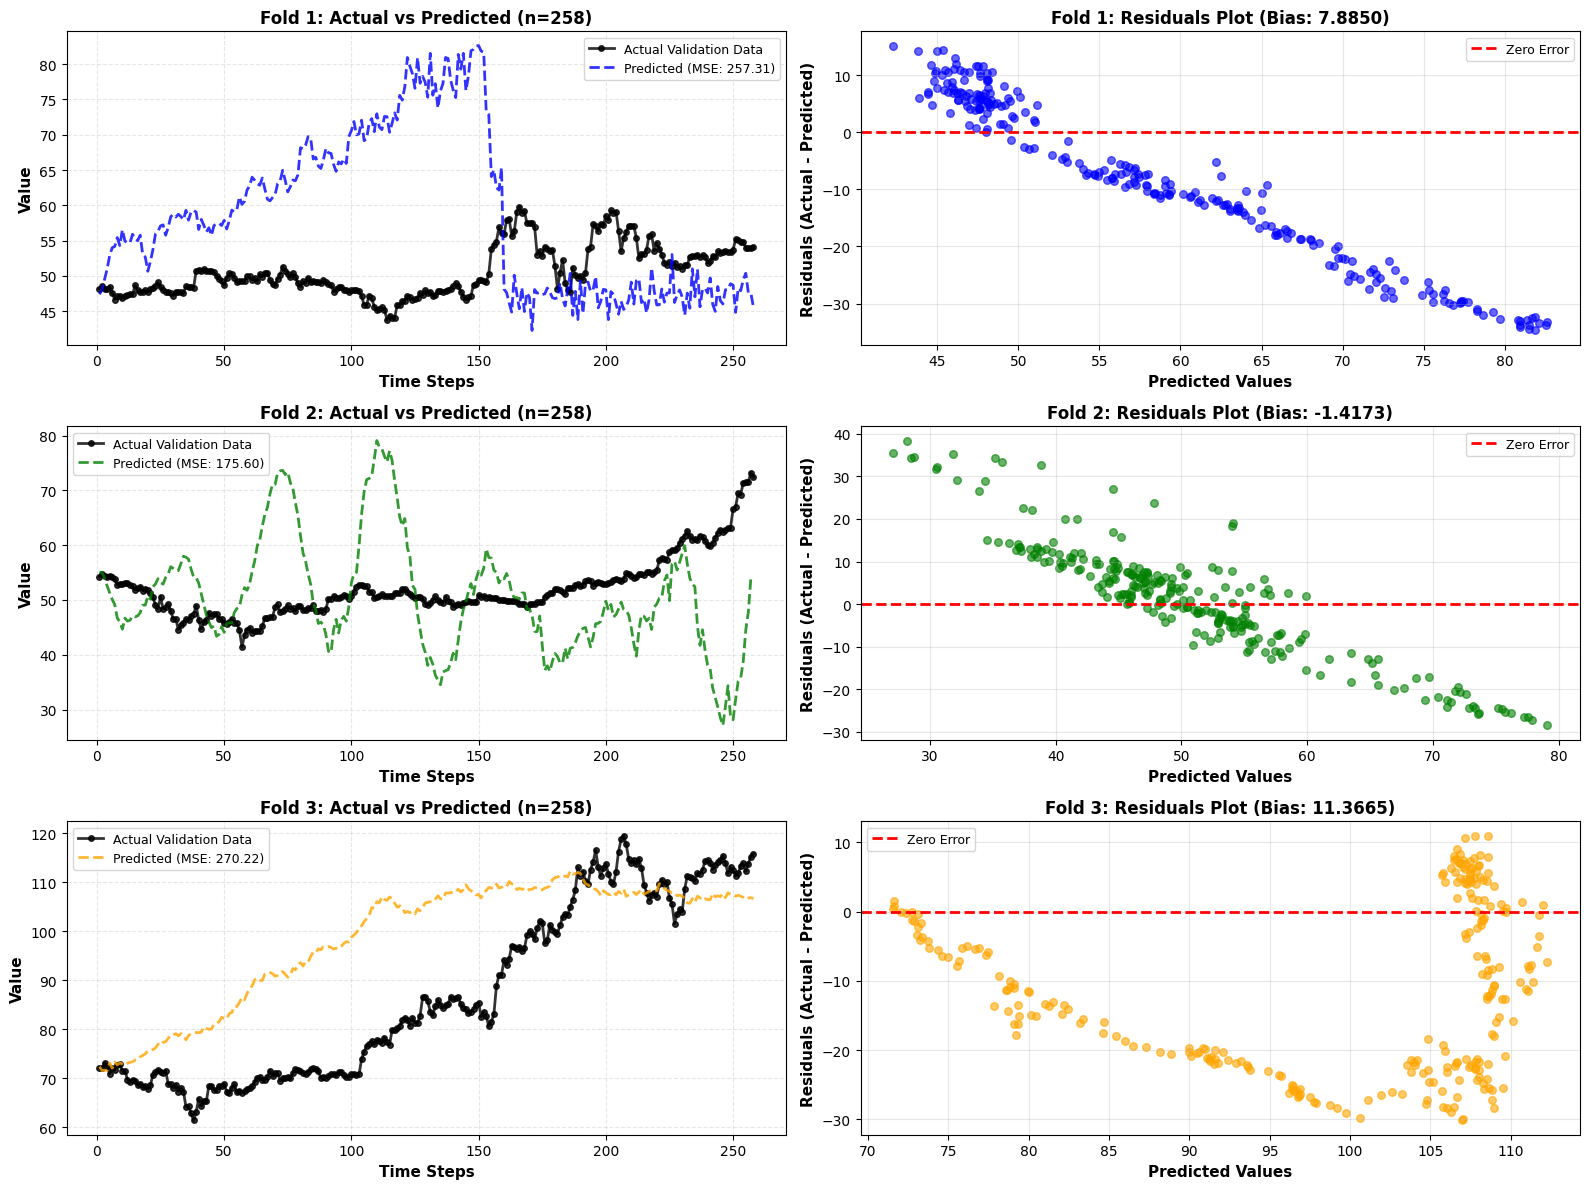

✓ Đã lưu biểu đồ tổng hợp: validation_3fold_combined.png


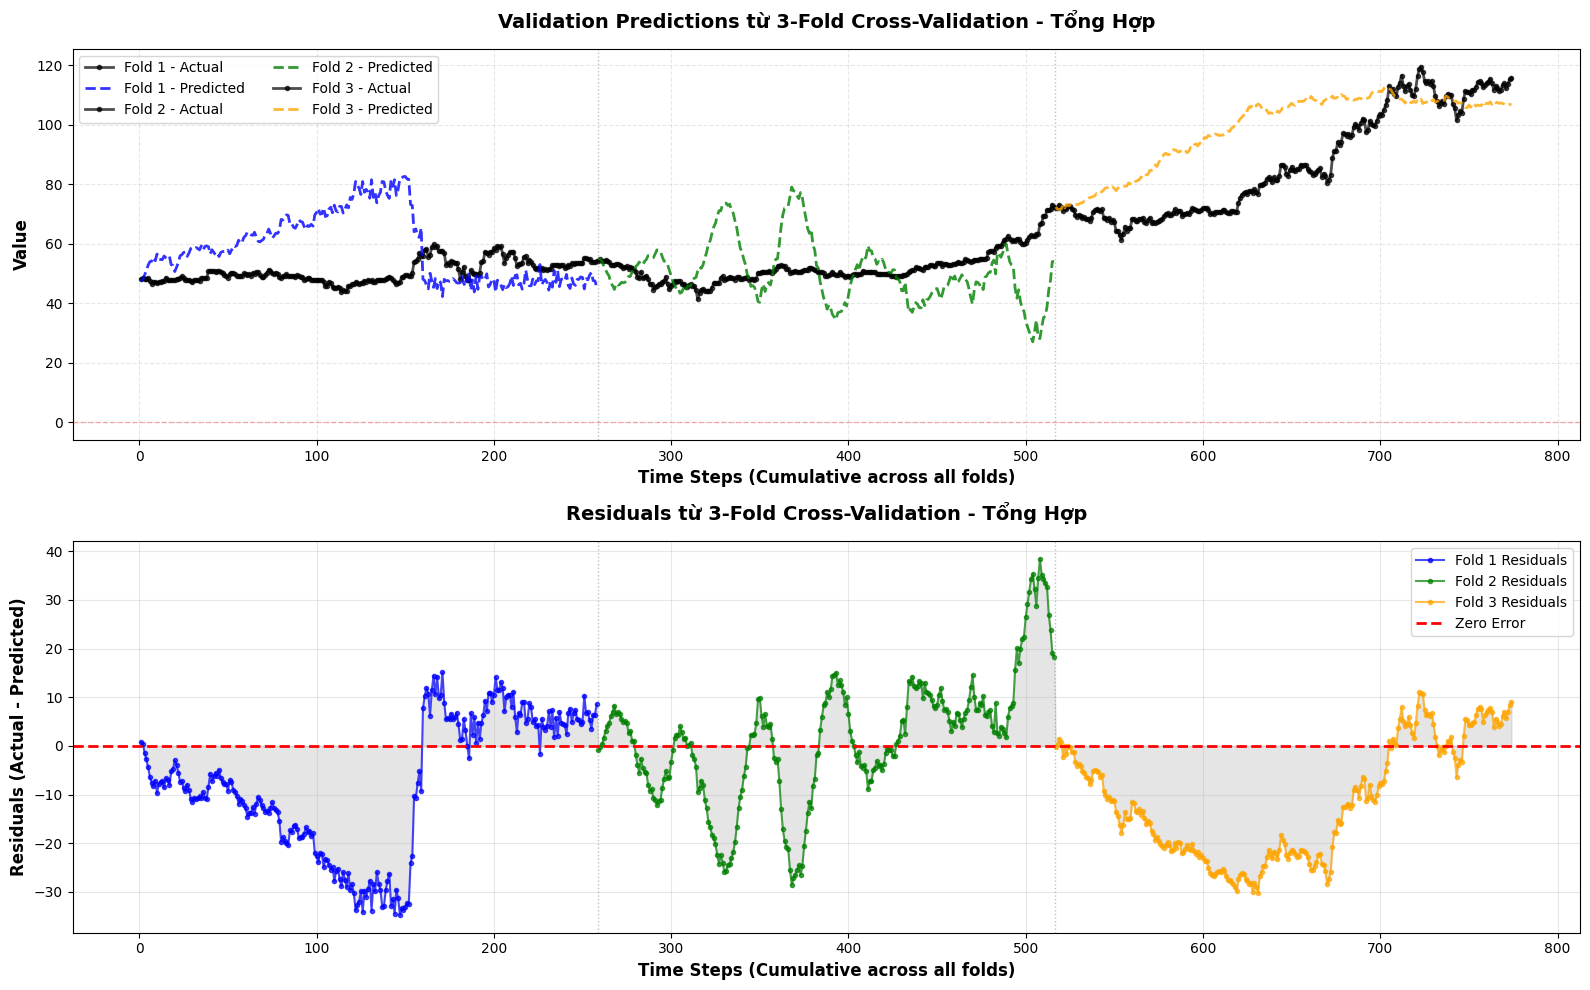


📊 TỔNG HỢP METRICS TỪ TẤT CẢ 3 FOLDS:
   - Total Samples: 774
   - MSE: 234.3772
   - RMSE: 15.3094
   - MAE: 12.3146
   - Bias: 5.9447
   - Mean Residual: -5.9447
   - Std Residual: 14.1081

✅ Hoàn thành phân tích validation predictions từ 3-fold cross-validation!


In [ ]:
print("="*70)
print("📊 PHÂN TÍCH VALIDATION PREDICTIONS TỪ 3-FOLD CROSS-VALIDATION")
print("="*70)

# Vẽ biểu đồ cho từng fold
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

colors = ['blue', 'green', 'orange']
fold_names = ['Fold 1', 'Fold 2', 'Fold 3']

for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        pred_fold = fold_predictions[fold_idx]
        actual_fold = fold_actuals[fold_idx]
        
        # Tính metrics cho fold này
        mse_fold = mean_squared_error(actual_fold, pred_fold)
        mae_fold = mean_absolute_error(actual_fold, pred_fold)
        rmse_fold = np.sqrt(mse_fold)
        bias_fold = np.mean(pred_fold - actual_fold)
        
        # Tính residuals
        residuals_fold = actual_fold - pred_fold
        
        # Subplot 1: Actual vs Predicted
        ax1 = axes[fold_idx, 0]
        x_axis = np.arange(1, len(actual_fold) + 1)
        ax1.plot(x_axis, actual_fold, 'o-', label='Actual Validation Data', 
                linewidth=2, markersize=4, color='black', alpha=0.8)
        ax1.plot(x_axis, pred_fold, '--', label=f'Predicted (MSE: {mse_fold:.2f})', 
                linewidth=2, color=colors[fold_idx], alpha=0.8)
        ax1.set_xlabel('Time Steps', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax1.set_title(f'{fold_names[fold_idx]}: Actual vs Predicted (n={len(actual_fold)})', 
                     fontsize=12, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3, linestyle='--')
        
        # Subplot 2: Residuals Plot
        ax2 = axes[fold_idx, 1]
        ax2.scatter(pred_fold, residuals_fold, alpha=0.6, s=30, color=colors[fold_idx])
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
        ax2.set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
        ax2.set_title(f'{fold_names[fold_idx]}: Residuals Plot (Bias: {bias_fold:.4f})', 
                     fontsize=12, fontweight='bold')
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        print(f"\n📊 {fold_names[fold_idx]} Statistics:")
        print(f"   - Samples: {len(actual_fold)}")
        print(f"   - MSE: {mse_fold:.4f}")
        print(f"   - RMSE: {rmse_fold:.4f}")
        print(f"   - MAE: {mae_fold:.4f}")
        print(f"   - Bias: {bias_fold:.4f}")

plt.tight_layout()
plt.savefig('validation_3fold_analysis.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Đã lưu biểu đồ: validation_3fold_analysis.png")
plt.show()

# Vẽ biểu đồ tổng hợp: Tất cả 3 folds trên cùng một biểu đồ
fig2, axes2 = plt.subplots(2, 1, figsize=(16, 10))

# Tính offset để vẽ các folds liên tiếp
cumulative_offset = 0
all_predictions = []
all_actuals = []
all_residuals = []
fold_boundaries = [0]

for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        pred_fold = fold_predictions[fold_idx]
        actual_fold = fold_actuals[fold_idx]
        residuals_fold = actual_fold - pred_fold
        
        x_axis_fold = np.arange(cumulative_offset + 1, cumulative_offset + len(actual_fold) + 1)
        
        # Subplot 1: Tất cả predictions và actuals
        axes2[0].plot(x_axis_fold, actual_fold, 'o-', 
                     label=f'{fold_names[fold_idx]} - Actual', 
                     linewidth=2, markersize=3, color='black', alpha=0.7)
        axes2[0].plot(x_axis_fold, pred_fold, '--', 
                     label=f'{fold_names[fold_idx]} - Predicted', 
                     linewidth=2, color=colors[fold_idx], alpha=0.8)
        
        # Subplot 2: Tất cả residuals
        axes2[1].plot(x_axis_fold, residuals_fold, 'o-', 
                     label=f'{fold_names[fold_idx]} Residuals', 
                     linewidth=1.5, markersize=3, color=colors[fold_idx], alpha=0.7)
        
        all_predictions.extend(pred_fold)
        all_actuals.extend(actual_fold)
        all_residuals.extend(residuals_fold)
        
        cumulative_offset += len(actual_fold)
        fold_boundaries.append(cumulative_offset)

# Vẽ đường phân cách giữa các folds
for boundary in fold_boundaries[1:-1]:
    axes2[0].axvline(x=boundary + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    axes2[1].axvline(x=boundary + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Subplot 1 settings
axes2[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.3)
axes2[0].set_xlabel('Time Steps (Cumulative across all folds)', fontsize=12, fontweight='bold')
axes2[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes2[0].set_title('Validation Predictions từ 3-Fold Cross-Validation - Tổng Hợp', 
                   fontsize=14, fontweight='bold', pad=15)
axes2[0].legend(loc='best', fontsize=10, ncol=2)
axes2[0].grid(True, alpha=0.3, linestyle='--')

# Subplot 2 settings
axes2[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes2[1].fill_between(range(1, len(all_residuals) + 1), all_residuals, 0, alpha=0.2, color='gray')
axes2[1].set_xlabel('Time Steps (Cumulative across all folds)', fontsize=12, fontweight='bold')
axes2[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes2[1].set_title('Residuals từ 3-Fold Cross-Validation - Tổng Hợp', 
                   fontsize=14, fontweight='bold', pad=15)
axes2[1].legend(loc='best', fontsize=10)
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_3fold_combined.png', dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ tổng hợp: validation_3fold_combined.png")
plt.show()

# Tính tổng hợp metrics từ tất cả folds
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)
all_residuals = np.array(all_residuals)

mse_all = mean_squared_error(all_actuals, all_predictions)
mae_all = mean_absolute_error(all_actuals, all_predictions)
rmse_all = np.sqrt(mse_all)
bias_all = np.mean(all_predictions - all_actuals)

print(f"\n📊 TỔNG HỢP METRICS TỪ TẤT CẢ 3 FOLDS:")
print(f"   - Total Samples: {len(all_actuals)}")
print(f"   - MSE: {mse_all:.4f}")
print(f"   - RMSE: {rmse_all:.4f}")
print(f"   - MAE: {mae_all:.4f}")
print(f"   - Bias: {bias_all:.4f}")
print(f"   - Mean Residual: {np.mean(all_residuals):.4f}")
print(f"   - Std Residual: {np.std(all_residuals):.4f}")

print(f"\n✅ Hoàn thành phân tích validation predictions từ 3-fold cross-validation!")


## 5.6. Biểu Đồ Tổng Thể: Training Data và 3-Fold Validation Predictions


📊 BIỂU ĐỒ TỔNG THỂ: TRAINING DATA VÀ 3-FOLD VALIDATION PREDICTIONS

🔍 Debug: Kiểm tra fold_indices:
   - Total training data points: 1033
   - Fold 1: Val indices range [259, 516] (n=258)
     → Vị trí trong biểu đồ: [260, 517]
     ✓ Actual values khớp với full_train_values tại vị trí này
   - Fold 2: Val indices range [517, 774] (n=258)
     → Vị trí trong biểu đồ: [518, 775]
     ✓ Actual values khớp với full_train_values tại vị trí này
   - Fold 3: Val indices range [775, 1032] (n=258)
     → Vị trí trong biểu đồ: [776, 1033]
     ✓ Actual values khớp với full_train_values tại vị trí này

🔍 Debug Fold 3 (cuối cùng):
   - len(val_indices): 258
   - len(pred_fold): 258
   - len(actual_fold): 258
   - min_len sẽ dùng: 258
   - val_indices range: [775, 1032]
   - Vị trí cuối trong biểu đồ: 1033
   - Total training data: 1033

✓ Đã lưu biểu đồ tổng thể: training_data_with_3fold_predictions.png


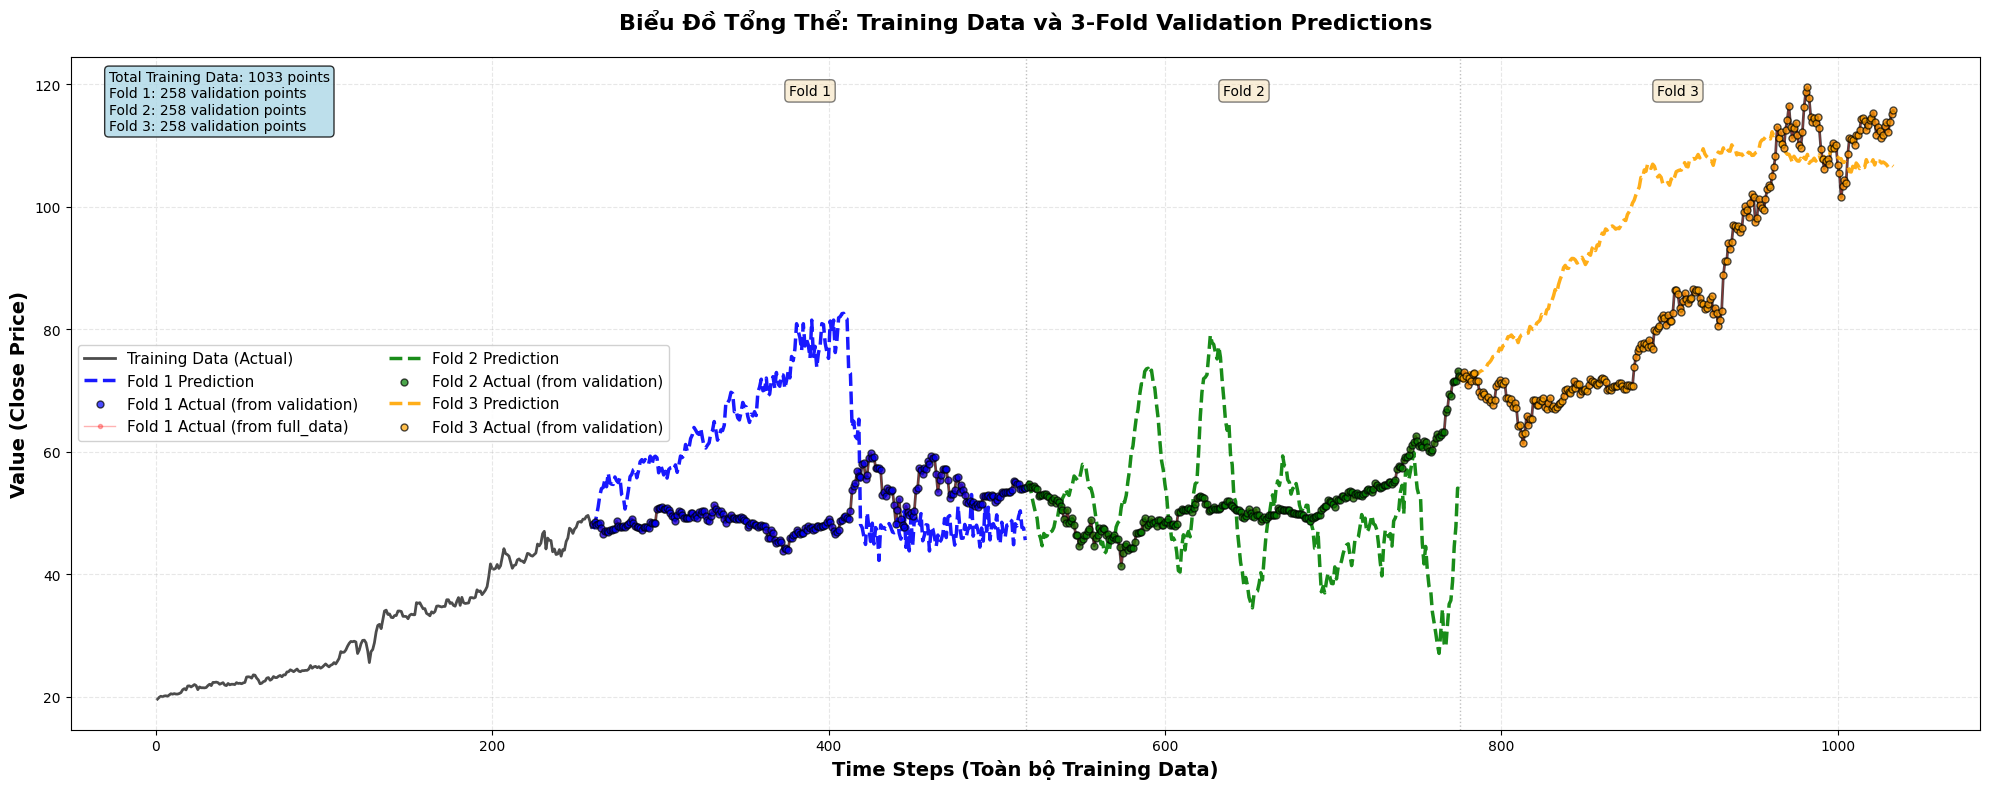

✓ Đã lưu biểu đồ zoom: training_data_with_3fold_predictions_zoom.png


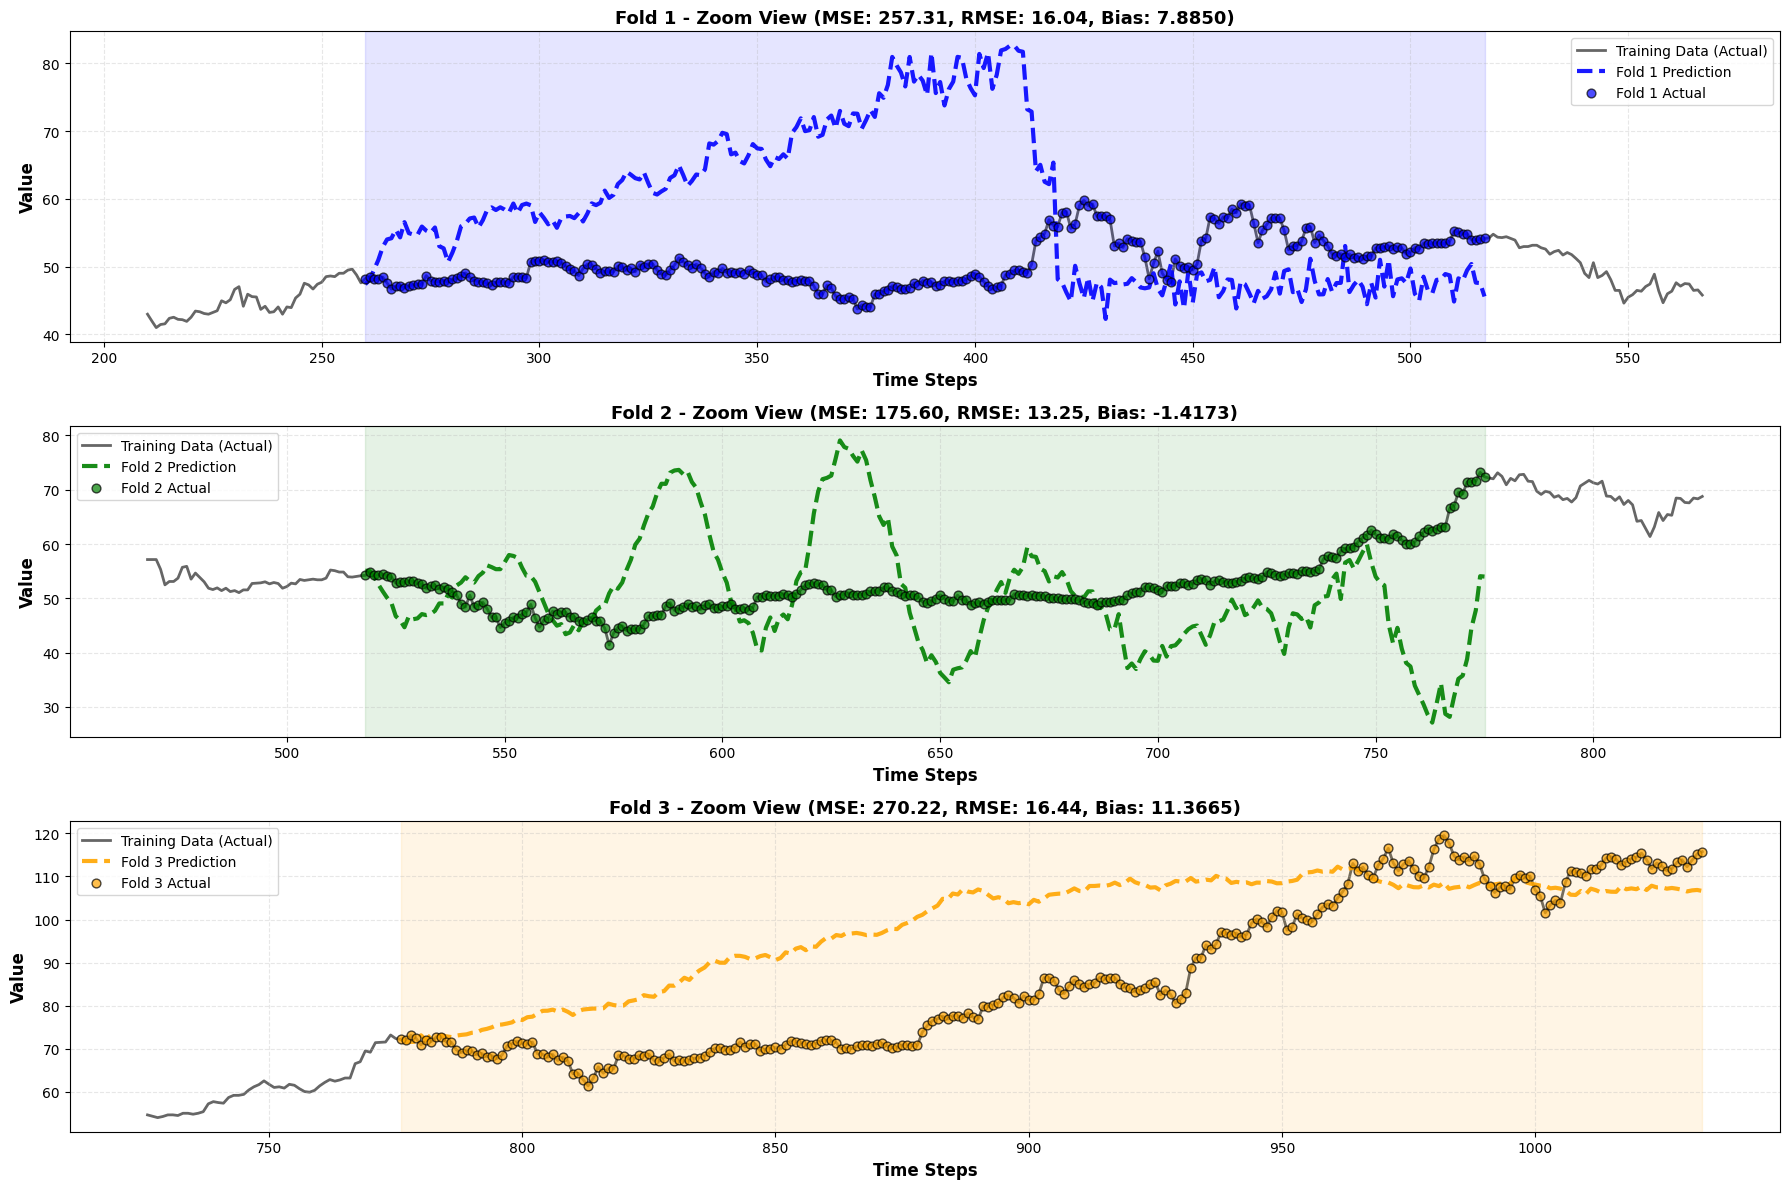


✅ Hoàn thành tạo biểu đồ tổng thể!


In [ ]:
print("="*70)
print("📊 BIỂU ĐỒ TỔNG THỂ: TRAINING DATA VÀ 3-FOLD VALIDATION PREDICTIONS")
print("="*70)

# Lấy toàn bộ training data
full_train_values = train_nf_full['y'].values
n_total = len(full_train_values)

# Debug: Kiểm tra fold_indices
print(f"\n🔍 Debug: Kiểm tra fold_indices:")
print(f"   - Total training data points: {n_total}")
for fold_idx in range(len(fold_indices)):
    val_indices = fold_indices[fold_idx]
    if len(val_indices) > 0:
        print(f"   - Fold {fold_idx + 1}: Val indices range [{val_indices[0]}, {val_indices[-1]}] (n={len(val_indices)})")
        print(f"     → Vị trí trong biểu đồ: [{val_indices[0] + 1}, {val_indices[-1] + 1}]")
        # Kiểm tra xem có khớp với actual values không
        if fold_idx < len(fold_actuals):
            actual_fold = fold_actuals[fold_idx]
            actual_from_full = full_train_values[val_indices]
            if np.allclose(actual_fold[:len(actual_from_full)], actual_from_full[:len(actual_fold)], rtol=1e-5):
                print(f"     ✓ Actual values khớp với full_train_values tại vị trí này")
            else:
                print(f"     ⚠️  Actual values KHÔNG khớp! Cần kiểm tra lại.")

# Tạo x-axis cho toàn bộ data
x_axis_full = np.arange(1, n_total + 1)

# Tạo figure lớn
fig, ax = plt.subplots(1, 1, figsize=(20, 8))

# Vẽ toàn bộ training data
ax.plot(x_axis_full, full_train_values, '-', 
        label='Training Data (Actual)', 
        linewidth=2, color='black', alpha=0.7, zorder=1)

# Vẽ 3 validation predictions tại đúng vị trí của chúng
colors = ['blue', 'green', 'orange']
fold_names = ['Fold 1 Prediction', 'Fold 2 Prediction', 'Fold 3 Prediction']

for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        # Lấy indices của validation fold này trong full_data
        val_indices = fold_indices[fold_idx]
        pred_fold = fold_predictions[fold_idx]
        actual_fold = fold_actuals[fold_idx]
        
        # Vẽ predictions tại đúng vị trí
        # val_indices là indices trong full_data (train_nf_full), cần chuyển sang 1-based index
        x_axis_fold = val_indices + 1  # Chuyển từ 0-based sang 1-based
        
        # Đảm bảo độ dài khớp
        min_len = min(len(x_axis_fold), len(pred_fold), len(actual_fold))
        
        # Debug: Kiểm tra độ dài
        if fold_idx == 2:  # Fold 3 (index 2)
            print(f"\n🔍 Debug Fold 3 (cuối cùng):")
            print(f"   - len(val_indices): {len(val_indices)}")
            print(f"   - len(pred_fold): {len(pred_fold)}")
            print(f"   - len(actual_fold): {len(actual_fold)}")
            print(f"   - min_len sẽ dùng: {min_len}")
            print(f"   - val_indices range: [{val_indices[0]}, {val_indices[-1]}]")
            print(f"   - Vị trí cuối trong biểu đồ: {val_indices[-1] + 1}")
            print(f"   - Total training data: {n_total}")
            if val_indices[-1] + 1 < n_total:
                print(f"   ⚠️  Có {n_total - (val_indices[-1] + 1)} điểm training data SAU fold 3!")
        
        x_axis_fold = x_axis_fold[:min_len]
        pred_fold = pred_fold[:min_len]
        actual_fold = actual_fold[:min_len]
        
        # Kiểm tra: Lấy actual values từ full_train_values tại đúng vị trí
        actual_from_full = full_train_values[val_indices[:min_len]]
        
        # Vẽ predictions
        ax.plot(x_axis_fold, pred_fold, '--', 
               label=fold_names[fold_idx], 
               linewidth=2.5, color=colors[fold_idx], alpha=0.9, zorder=2)
        
        # Vẽ actual validation data từ fold_actuals (đã lưu)
        ax.scatter(x_axis_fold, actual_fold, 
                  s=25, color=colors[fold_idx], alpha=0.7, 
                  marker='o', zorder=3, edgecolors='black', linewidths=1,
                  label=f'Fold {fold_idx+1} Actual (from validation)')
        
        # Vẽ actual từ full_train_values để xác nhận vị trí đúng
        ax.plot(x_axis_fold, actual_from_full, 
               'o-', linewidth=1, markersize=3, 
               color='red', alpha=0.3, zorder=1,
               label=f'Fold {fold_idx+1} Actual (from full_data)' if fold_idx == 0 else '')

# Vẽ đường phân cách giữa các folds
fold_boundaries = []
for fold_idx in range(3):
    if fold_idx < len(fold_indices):
        val_indices = fold_indices[fold_idx]
        if len(val_indices) > 0:
            start_idx = val_indices[0] + 1
            end_idx = val_indices[-1] + 1
            if fold_idx == 0:
                fold_boundaries.append(start_idx)
            fold_boundaries.append(end_idx)

# Kiểm tra xem có dữ liệu training sau fold 3 không
last_fold_end = fold_boundaries[-1] if len(fold_boundaries) > 0 else n_total
if last_fold_end < n_total:
    print(f"\n⚠️  Phát hiện: Có {n_total - last_fold_end} điểm training data SAU validation fold cuối cùng!")
    print(f"   - Validation fold cuối kết thúc ở: {last_fold_end}")
    print(f"   - Training data kết thúc ở: {n_total}")
    print(f"   - Phần dữ liệu này KHÔNG được dùng cho validation trong 3-fold CV")

# Vẽ đường phân cách giữa các folds
for boundary in fold_boundaries[1:-1]:
    ax.axvline(x=boundary + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Highlight phần training data sau validation folds (nếu có)
if last_fold_end < n_total:
    ax.axvspan(last_fold_end, n_total, alpha=0.1, color='yellow', 
              label='Training Data (không dùng trong 3-fold CV)')

# Thêm annotations cho các folds
for fold_idx in range(3):
    if fold_idx < len(fold_indices):
        val_indices = fold_indices[fold_idx]
        if len(val_indices) > 0:
            mid_idx = val_indices[len(val_indices)//2] + 1
            ax.text(mid_idx, ax.get_ylim()[1] * 0.95, 
                   f'Fold {fold_idx+1}', 
                   fontsize=10, ha='center', 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Labels và title
ax.set_xlabel('Time Steps (Toàn bộ Training Data)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Close Price)', fontsize=14, fontweight='bold')
ax.set_title('Biểu Đồ Tổng Thể: Training Data và 3-Fold Validation Predictions', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

# Thêm text box với thông tin
info_text = f'Total Training Data: {n_total} points\n'
info_text += f'Fold 1: {len(fold_predictions[0]) if len(fold_predictions) > 0 else 0} validation points\n'
info_text += f'Fold 2: {len(fold_predictions[1]) if len(fold_predictions) > 1 else 0} validation points\n'
info_text += f'Fold 3: {len(fold_predictions[2]) if len(fold_predictions) > 2 else 0} validation points'

ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
       fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('training_data_with_3fold_predictions.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Đã lưu biểu đồ tổng thể: training_data_with_3fold_predictions.png")
plt.show()

# Tạo biểu đồ zoom vào các vùng validation để xem chi tiết hơn
fig2, axes2 = plt.subplots(3, 1, figsize=(18, 12))

for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        val_indices = fold_indices[fold_idx]
        pred_fold = fold_predictions[fold_idx]
        actual_fold = fold_actuals[fold_idx]
        
        # Tính vùng xung quanh validation để hiển thị context
        val_start = val_indices[0]
        val_end = val_indices[-1]
        
        # Mở rộng thêm 50 điểm trước và sau để có context
        context_start = max(0, val_start - 50)
        context_end = min(n_total - 1, val_end + 50)
        
        x_context = np.arange(context_start + 1, context_end + 2)
        y_context = full_train_values[context_start:context_end + 1]
        
        # Vẽ training data trong vùng context
        axes2[fold_idx].plot(x_context, y_context, '-', 
                            label='Training Data (Actual)', 
                            linewidth=2, color='black', alpha=0.6, zorder=1)
        
        # Vẽ validation predictions
        x_axis_fold = val_indices + 1
        min_len = min(len(x_axis_fold), len(pred_fold))
        x_axis_fold = x_axis_fold[:min_len]
        pred_fold_plot = pred_fold[:min_len]
        actual_fold_plot = actual_fold[:min_len]
        
        axes2[fold_idx].plot(x_axis_fold, pred_fold_plot, '--', 
                            label=f'Fold {fold_idx+1} Prediction', 
                            linewidth=3, color=colors[fold_idx], alpha=0.9, zorder=2)
        
        # Vẽ actual validation data
        axes2[fold_idx].scatter(x_axis_fold, actual_fold_plot, 
                               s=40, color=colors[fold_idx], alpha=0.7, 
                               marker='o', zorder=3, edgecolors='black', linewidths=1,
                               label=f'Fold {fold_idx+1} Actual')
        
        # Tính metrics
        mse_fold = mean_squared_error(actual_fold_plot, pred_fold_plot)
        rmse_fold = np.sqrt(mse_fold)
        bias_fold = np.mean(pred_fold_plot - actual_fold_plot)
        
        axes2[fold_idx].set_xlabel('Time Steps', fontsize=12, fontweight='bold')
        axes2[fold_idx].set_ylabel('Value', fontsize=12, fontweight='bold')
        axes2[fold_idx].set_title(f'Fold {fold_idx+1} - Zoom View (MSE: {mse_fold:.2f}, RMSE: {rmse_fold:.2f}, Bias: {bias_fold:.4f})', 
                                  fontsize=13, fontweight='bold')
        axes2[fold_idx].legend(loc='best', fontsize=10)
        axes2[fold_idx].grid(True, alpha=0.3, linestyle='--')
        
        # Highlight vùng validation
        axes2[fold_idx].axvspan(val_start + 1, val_end + 1, alpha=0.1, color=colors[fold_idx])

plt.tight_layout()
plt.savefig('training_data_with_3fold_predictions_zoom.png', dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ zoom: training_data_with_3fold_predictions_zoom.png")
plt.show()

print(f"\n✅ Hoàn thành tạo biểu đồ tổng thể!")


## 6. Áp Dụng Smooth Bias Correction (Linear 20% - Best Method)


In [ ]:
print("="*70)
print("🔧 ÁP DỤNG SMOOTH BIAS CORRECTION (LINEAR 20% - BEST METHOD)")
print("="*70)
print("\n💡 Phương pháp KẾT HỢP:")
print("   - Phần đầu (20%): Smooth transition (giữ nguyên giá trị đầu)")
print("   - Phần cuối (80%): Post-processing Regression (Linear Regression)")
print("="*70)

def smooth_bias_correction_with_postprocessing(pred_baseline, post_model, method='linear', smooth_ratio=0.2):
    """
    Áp dụng smooth bias correction kết hợp với post-processing regression:
    - Giai đoạn đầu (smooth_ratio%): smooth transition (giữ nguyên giá trị đầu)
    - Giai đoạn cuối (1-smooth_ratio%): post-processing regression

    Parameters:
    -----------
    pred_baseline : array
        Predictions từ baseline model
    post_model : sklearn model
        Post-processing regression model (LinearRegression)
    method : str
        Phương pháp smooth: 'linear' (best method)
    smooth_ratio : float
        Tỷ lệ phần đầu smooth (default: 0.2 = 20%)

    Returns:
    --------
    pred_corrected : array
        Predictions sau khi điều chỉnh
    weights : array
        Trọng số interpolation giữa baseline và post-processing
    """
    n = len(pred_baseline)

    # Tính post-processing predictions
    pred_post = post_model.predict(pred_baseline.reshape(-1, 1))

    # Tính weights cho smooth transition
    weights = np.zeros(n)

    # Tính điểm chia: smooth_ratio% đầu smooth, phần còn lại traditional
    split_point = int(n * smooth_ratio)
    if split_point < 1:
        split_point = 1
    if split_point >= n - 1:
        split_point = max(1, n - 2)

    # Phần đầu: smooth transition từ baseline đến post-processing
    if split_point > 1:
        smooth_part = split_point
        if method == 'linear':
            smooth_weights = np.arange(smooth_part) / max(smooth_part - 1, 1)
        else:
            smooth_weights = np.arange(smooth_part) / max(smooth_part - 1, 1)

        # Normalize để weight[split_point-1] = 1.0
        if smooth_weights[-1] > 0:
            smooth_weights = smooth_weights / smooth_weights[-1]
        else:
            smooth_weights = np.arange(smooth_part) / max(smooth_part - 1, 1)

        weights[:split_point] = smooth_weights
        weights[0] = 0.0  # Giữ nguyên điểm đầu (weight=0 → dùng baseline)
        weights[split_point - 1] = 1.0  # Điểm cuối phần smooth (weight=1 → dùng post-processing)

    # Phần cuối: post-processing regression (weight = 1.0)
    weights[split_point:] = 1.0

    # Đảm bảo: weight[0] = 0 (giữ nguyên giá trị đầu = baseline)
    # và weight[-1] = 1 (giá trị cuối = post-processing)
    weights[0] = 0.0
    weights[-1] = 1.0

    # Interpolation: pred = (1-weight) * baseline + weight * post_processing
    pred_corrected = (1 - weights) * pred_baseline + weights * pred_post

    # Đảm bảo phần cuối = post-processing
    if split_point < len(pred_corrected):
        pred_corrected[split_point:] = pred_post[split_point:]
        weights[split_point:] = 1.0

    return pred_corrected, weights

# Áp dụng Smooth Linear 20% (best method)
smooth_ratio = 0.2  # 20% đầu smooth
pred_smooth, weights = smooth_bias_correction_with_postprocessing(
    pred_patchtst_baseline,
    best_post_model,
    method='linear',
    smooth_ratio=smooth_ratio
)

# Đánh giá
mse_smooth = mean_squared_error(y_true, pred_smooth)
mae_smooth = mean_absolute_error(y_true, pred_smooth)
rmse_smooth = np.sqrt(mse_smooth)
r2_smooth = r2_score(y_true, pred_smooth)
mape_smooth = np.mean(np.abs((y_true - pred_smooth) / y_true)) * 100
bias_smooth = np.mean(pred_smooth - y_true)

# Kiểm tra giá trị đầu tiên và cuối cùng
first_value_preserved = np.isclose(pred_smooth[0], pred_patchtst_baseline[0], rtol=1e-5)
pred_post_best = best_post_model.predict(pred_patchtst_baseline.reshape(-1, 1))
last_value_matches_postprocessing = np.isclose(pred_smooth[-1], pred_post_best[-1], rtol=1e-5)

print(f"\n📊 Smooth Linear 20% Results (BEST METHOD):")
print(f"   - MSE: {mse_smooth:.4f} (Baseline: {mse_baseline:.4f}, Post-processing: {mse_post:.4f})")
print(f"   - RMSE: {rmse_smooth:.4f}")
print(f"   - MAE: {mae_smooth:.4f}")
print(f"   - R²: {r2_smooth:.4f}")
print(f"   - MAPE: {mape_smooth:.2f}%")
print(f"   - Bias: {bias_smooth:.4f}")
print(f"   - Giá trị đầu: {pred_smooth[0]:.4f} (Baseline: {pred_patchtst_baseline[0]:.4f}, Giữ nguyên: {first_value_preserved})")
print(f"   - Giá trị cuối: {pred_smooth[-1]:.4f} (Post-processing: {pred_post_best[-1]:.4f}, Khớp: {last_value_matches_postprocessing})")

improvement_vs_baseline = ((mse_baseline - mse_smooth) / mse_baseline) * 100
improvement_vs_post = ((mse_post - mse_smooth) / mse_post) * 100

print(f"\n💡 Cải thiện:")
print(f"   - So với Baseline: {improvement_vs_baseline:+.2f}%")
print(f"   - So với Post-processing: {improvement_vs_post:+.2f}%")


🔧 ÁP DỤNG SMOOTH BIAS CORRECTION (LINEAR 20% - BEST METHOD)

💡 Phương pháp KẾT HỢP:
   - Phần đầu (20%): Smooth transition (giữ nguyên giá trị đầu)
   - Phần cuối (80%): Post-processing Regression (Linear Regression)

📊 Smooth Linear 20% Results (BEST METHOD):
   - MSE: 17.4927 (Baseline: 641.4994, Post-processing: 44.9403)
   - RMSE: 4.1824
   - MAE: 3.4786
   - R²: 0.4947
   - MAPE: 3.43%
   - Bias: 1.7849
   - Giá trị đầu: 116.5001 (Baseline: 116.5001, Giữ nguyên: True)
   - Giá trị cuối: 110.2748 (Post-processing: 110.2748, Khớp: True)

💡 Cải thiện:
   - So với Baseline: +97.27%
   - So với Post-processing: +61.08%


## 6.5. Biểu Đồ So Sánh Kết Quả với Thực Tế


📊 VẼ BIỂU ĐỒ SO SÁNH KẾT QUẢ VỚI THỰC TẾ

✓ Đã lưu biểu đồ: forecast_comparison.png


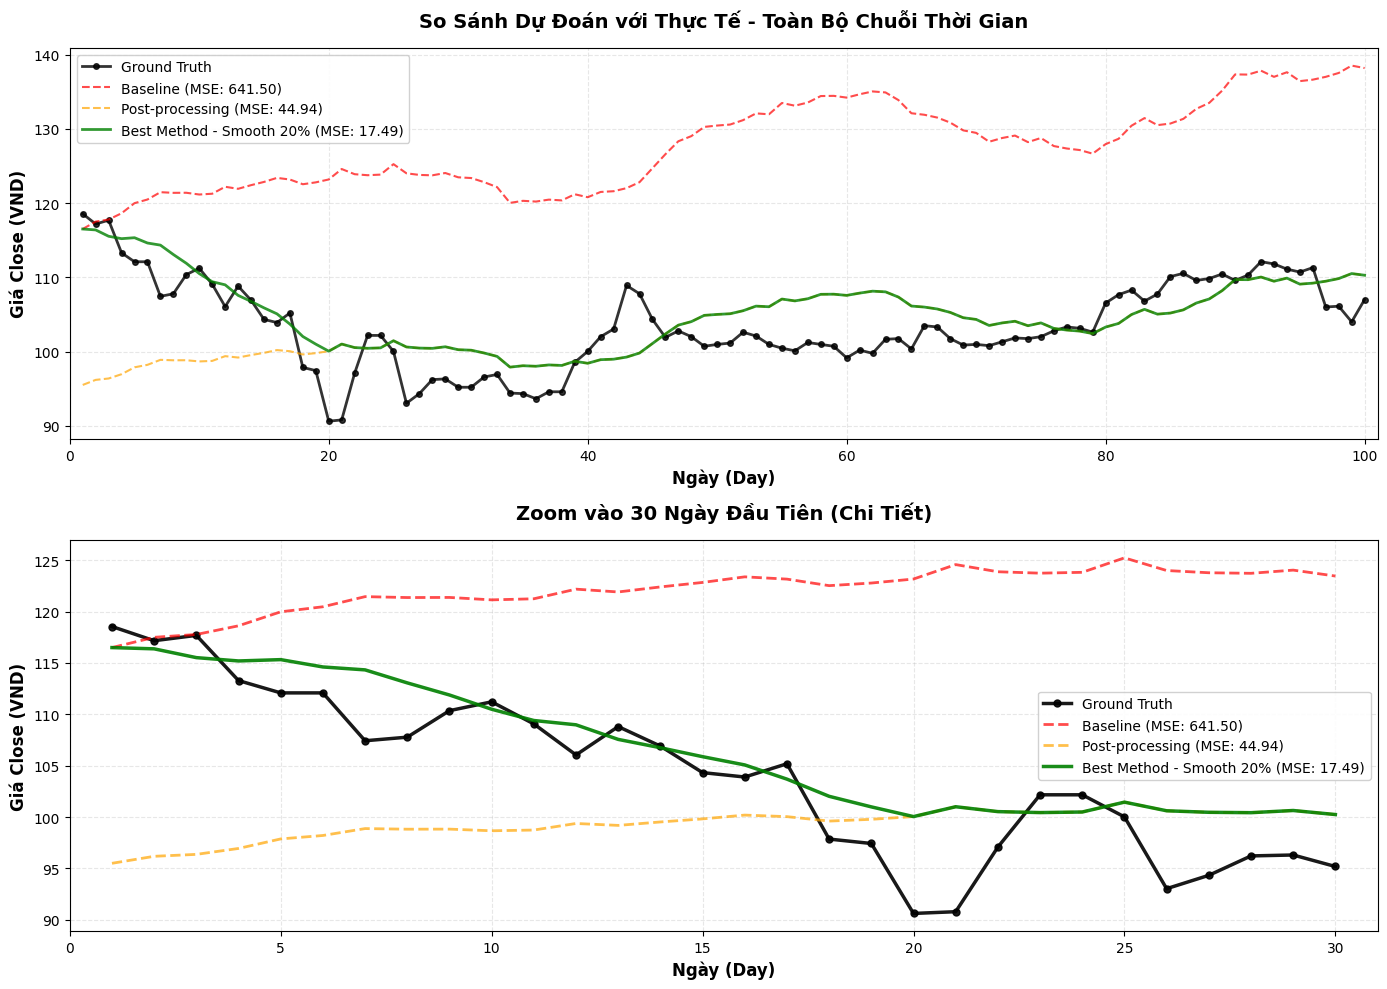

In [ ]:
print("="*70)
print("📊 VẼ BIỂU ĐỒ SO SÁNH KẾT QUẢ VỚI THỰC TẾ")
print("="*70)

# Chuẩn bị dữ liệu cho biểu đồ
n_points = len(y_true)
x_axis = np.arange(1, n_points + 1)

# Đảm bảo tất cả predictions có cùng độ dài
pred_baseline_plot = pred_patchtst_baseline[:n_points]
pred_post_plot = pred_post[:n_points]
pred_smooth_plot = pred_smooth[:n_points]
y_true_plot = y_true[:n_points]

# Tạo figure với 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Toàn bộ chuỗi thời gian
ax1 = axes[0]
ax1.plot(x_axis, y_true_plot, 'o-', label='Ground Truth', linewidth=2, markersize=4, color='black', alpha=0.8)
ax1.plot(x_axis, pred_baseline_plot, '--', label=f'Baseline (MSE: {mse_baseline:.2f})', linewidth=1.5, alpha=0.7, color='red')
ax1.plot(x_axis, pred_post_plot, '--', label=f'Post-processing (MSE: {mse_post:.2f})', linewidth=1.5, alpha=0.7, color='orange')
ax1.plot(x_axis, pred_smooth_plot, '-', label=f'Best Method - Smooth 20% (MSE: {mse_smooth:.2f})', linewidth=2, color='green', alpha=0.8)

ax1.set_xlabel('Ngày (Day)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Giá Close (VND)', fontsize=12, fontweight='bold')
ax1.set_title('So Sánh Dự Đoán với Thực Tế - Toàn Bộ Chuỗi Thời Gian', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, n_points + 1)

# Subplot 2: Zoom vào 30 ngày đầu
zoom_days = min(30, n_points)
ax2 = axes[1]
ax2.plot(x_axis[:zoom_days], y_true_plot[:zoom_days], 'o-', label='Ground Truth', linewidth=2.5, markersize=5, color='black', alpha=0.9)
ax2.plot(x_axis[:zoom_days], pred_baseline_plot[:zoom_days], '--', label=f'Baseline (MSE: {mse_baseline:.2f})', linewidth=2, alpha=0.7, color='red')
ax2.plot(x_axis[:zoom_days], pred_post_plot[:zoom_days], '--', label=f'Post-processing (MSE: {mse_post:.2f})', linewidth=2, alpha=0.7, color='orange')
ax2.plot(x_axis[:zoom_days], pred_smooth_plot[:zoom_days], '-', label=f'Best Method - Smooth 20% (MSE: {mse_smooth:.2f})', linewidth=2.5, color='green', alpha=0.9)

ax2.set_xlabel('Ngày (Day)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Giá Close (VND)', fontsize=12, fontweight='bold')
ax2.set_title(f'Zoom vào {zoom_days} Ngày Đầu Tiên (Chi Tiết)', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, zoom_days + 1)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Đã lưu biểu đồ: forecast_comparison.png")
plt.show()



📊 THỐNG KÊ LỖI:
Phương pháp               MSE          RMSE         MAE          Bias        
----------------------------------------------------------------------
Baseline                  641.4994     25.3278      24.1459      24.1049     
Post-processing           44.9403      6.7038       5.0698       -0.4263     
Smooth 20% (Best)         17.4927      4.1824       3.4786       1.7849      
✓ Đã lưu biểu đồ residuals: residuals_analysis.png


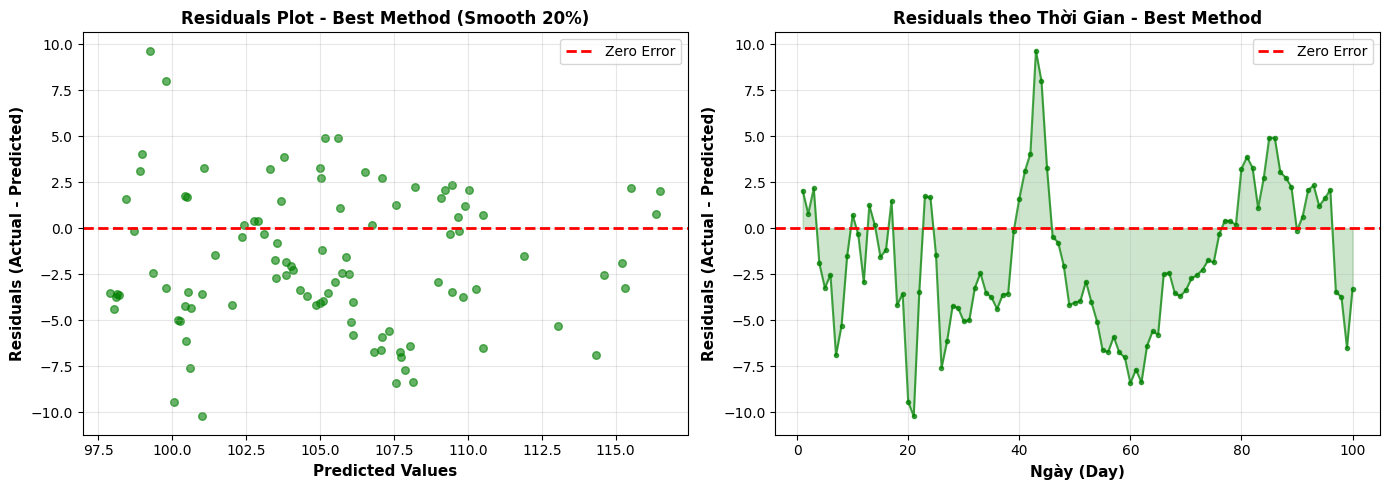


✅ Hoàn thành vẽ biểu đồ!


In [ ]:
# Tính toán và hiển thị thống kê lỗi
print(f"\n📊 THỐNG KÊ LỖI:")
print(f"{'Phương pháp':<25} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'Bias':<12}")
print("-" * 70)
print(f"{'Baseline':<25} {mse_baseline:<12.4f} {rmse_baseline:<12.4f} {mae_baseline:<12.4f} {bias_baseline:<12.4f}")
print(f"{'Post-processing':<25} {mse_post:<12.4f} {rmse_post:<12.4f} {mae_post:<12.4f} {bias_post:<12.4f}")
print(f"{'Smooth 20% (Best)':<25} {mse_smooth:<12.4f} {rmse_smooth:<12.4f} {mae_smooth:<12.4f} {bias_smooth:<12.4f}")

# Vẽ biểu đồ lỗi (residuals)
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Residuals plot cho best method
residuals_best = y_true_plot - pred_smooth_plot
axes2[0].scatter(pred_smooth_plot, residuals_best, alpha=0.6, s=30, color='green')
axes2[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes2[0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes2[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
axes2[0].set_title('Residuals Plot - Best Method (Smooth 20%)', fontsize=12, fontweight='bold')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Time series của residuals
axes2[1].plot(x_axis, residuals_best, 'o-', linewidth=1.5, markersize=3, color='green', alpha=0.7)
axes2[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes2[1].fill_between(x_axis, residuals_best, 0, alpha=0.2, color='green')
axes2[1].set_xlabel('Ngày (Day)', fontsize=11, fontweight='bold')
axes2[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11, fontweight='bold')
axes2[1].set_title('Residuals theo Thời Gian - Best Method', fontsize=12, fontweight='bold')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ residuals: residuals_analysis.png")
plt.show()

print(f"\n✅ Hoàn thành vẽ biểu đồ!")


## 7. Xuất File Submission


In [ ]:
print("="*70)
print("💾 XUẤT FILE SUBMISSION")
print("="*70)

# Sử dụng predictions từ best method (Smooth Linear 20%)
final_predictions = pred_smooth.copy()

print(f"\n📊 Sử dụng phương pháp: Smooth Linear 20% + Post-processing (Linear Regression)")
print(f"   - MSE: {mse_smooth:.4f}")
print(f"   - Bias: {bias_smooth:.4f}")

# Đảm bảo có đủ 100 predictions
if len(final_predictions) < horizon:
    print(f"\n⚠️  Chỉ có {len(final_predictions)} predictions, cần {horizon}")
    final_predictions = np.pad(final_predictions, (0, horizon - len(final_predictions)), mode='edge')
    print(f"   ✓ Đã pad lên {len(final_predictions)} predictions")
elif len(final_predictions) > horizon:
    final_predictions = final_predictions[:horizon]
    print(f"\n⚠️  Có {len(final_predictions)} predictions, chỉ lấy {horizon} đầu tiên")

# Đảm bảo không có giá trị âm hoặc NaN
final_predictions = np.maximum(final_predictions, 0)  # Không cho giá trị âm
if np.isnan(final_predictions).any():
    print("   ⚠️  Phát hiện NaN, thay thế bằng giá trị trung bình")
    final_predictions = np.nan_to_num(final_predictions, nan=np.nanmean(final_predictions))

# Tạo submission file
submission = pd.DataFrame({
    "id": np.arange(1, horizon + 1),  # id từ 1 đến 100
    "close": final_predictions
})

# Validation: Kiểm tra format
assert len(submission) == horizon, f"Số dòng phải là {horizon}, nhưng có {len(submission)}"
assert list(submission.columns) == ["id", "close"], f"Columns phải là ['id', 'close'], nhưng có {list(submission.columns)}"
assert submission["id"].min() == 1, f"id phải bắt đầu từ 1, nhưng min là {submission['id'].min()}"
assert submission["id"].max() == horizon, f"id phải kết thúc ở {horizon}, nhưng max là {submission['id'].max()}"
assert not submission["close"].isna().any(), "Không được có NaN trong cột close"
assert (submission["close"] >= 0).all(), "Giá trị close không được âm"

# Tên file submission
submission_file = "submission_patchtst_fixed_params.csv"
submission.to_csv(submission_file, index=False)

print(f"\n✓ Đã tạo submission file: {submission_file}")
print(f"   - Shape: {submission.shape}")
print(f"   - Columns: {list(submission.columns)}")

print(f"\n📊 Thống kê predictions:")
print(f"   - Min: {final_predictions.min():.2f}")
print(f"   - Max: {final_predictions.max():.2f}")
print(f"   - Mean: {final_predictions.mean():.2f}")
print(f"   - Std: {final_predictions.std():.2f}")
print(f"   - Median: {np.median(final_predictions):.2f}")

print(f"\n📅 10 dòng đầu:")
print(submission.head(10).to_string(index=False))
print(f"\n📅 10 dòng cuối:")
print(submission.tail(10).to_string(index=False))

print(f"\n✅ Hoàn thành xuất file submission!")


💾 XUẤT FILE SUBMISSION

📊 Sử dụng phương pháp: Smooth Linear 20% + Post-processing (Linear Regression)
   - MSE: 17.4927
   - Bias: 1.7849

✓ Đã tạo submission file: submission_patchtst_fixed_params.csv
   - Shape: (100, 2)
   - Columns: ['id', 'close']

📊 Thống kê predictions:
   - Min: 97.90
   - Max: 116.50
   - Mean: 105.27
   - Std: 4.61
   - Median: 105.08

📅 10 dòng đầu:
 id      close
  1 116.500084
  2 116.378200
  3 115.522782
  4 115.199187
  5 115.328029
  6 114.614345
  7 114.329612
  8 113.063744
  9 111.885776
 10 110.498076

📅 10 dòng cuối:
 id      close
 91 109.675865
 92 110.033646
 93 109.468758
 94 109.889809
 95 109.076164
 96 109.210381
 97 109.469719
 98 109.824867
 99 110.500816
100 110.274757

✅ Hoàn thành xuất file submission!


## 8. Tổng Kết


In [ ]:
print("="*70)
print("📊 TỔNG KẾT VÀ KẾT LUẬN")
print("="*70)

print(f"\n🎯 KẾT QUẢ:")
print(f"   - Baseline (PatchTST với Fixed Parameters): MSE = {mse_baseline:.4f}, Bias = {bias_baseline:.4f}")
print(f"   - Post-processing (Linear Regression): MSE = {mse_post:.4f}, Bias = {bias_post:.4f}")
print(f"   - Best Method (Smooth Linear 20%): MSE = {mse_smooth:.4f}, Bias = {bias_smooth:.4f}")

improvement_vs_baseline = ((mse_baseline - mse_smooth) / mse_baseline) * 100
improvement_vs_post = ((mse_post - mse_smooth) / mse_post) * 100

print(f"\n💡 CẢI THIỆN:")
print(f"   - So với Baseline: {improvement_vs_baseline:+.2f}%")
print(f"   - So với Post-processing: {improvement_vs_post:+.2f}%")

print(f"\n✅ Phương pháp Smooth Linear 20% + Post-processing (Linear Regression) là BEST METHOD")
print(f"   ✓ Cải thiện được {improvement_vs_baseline:.2f}% so với baseline")
print(f"   ✓ Bias đã được giảm từ {bias_baseline:.4f} xuống {bias_smooth:.4f}")
print(f"   ✓ File submission đã được tạo: submission_patchtst_fixed_params.csv")

print(f"\n📋 THÔNG SỐ ĐÃ SỬ DỤNG:")
for key, value in best_params_patchtst.items():
    print(f"   - {key}: {value}")


📊 TỔNG KẾT VÀ KẾT LUẬN

🎯 KẾT QUẢ:
   - Baseline (PatchTST với Fixed Parameters): MSE = 641.4994, Bias = 24.1049
   - Post-processing (Linear Regression): MSE = 44.9403, Bias = -0.4263
   - Best Method (Smooth Linear 20%): MSE = 17.4927, Bias = 1.7849

💡 CẢI THIỆN:
   - So với Baseline: +97.27%
   - So với Post-processing: +61.08%

✅ Phương pháp Smooth Linear 20% + Post-processing (Linear Regression) là BEST METHOD
   ✓ Cải thiện được 97.27% so với baseline
   ✓ Bias đã được giảm từ 24.1049 xuống 1.7849
   ✓ File submission đã được tạo: submission_patchtst_fixed_params.csv

📋 THÔNG SỐ ĐÃ SỬ DỤNG:
   - input_size: 100
   - patch_len: 32
   - stride: 4
   - learning_rate: 0.001610814898983045
   - max_steps: 250


## 9. Biểu Đồ Tổng Thể: Training + Test Data và Tất Cả Predictions


📊 BIỂU ĐỒ TỔNG THỂ: TRAINING + TEST DATA VÀ TẤT CẢ PREDICTIONS

✓ Đã lưu biểu đồ tổng thể: complete_overview_training_test_predictions.png


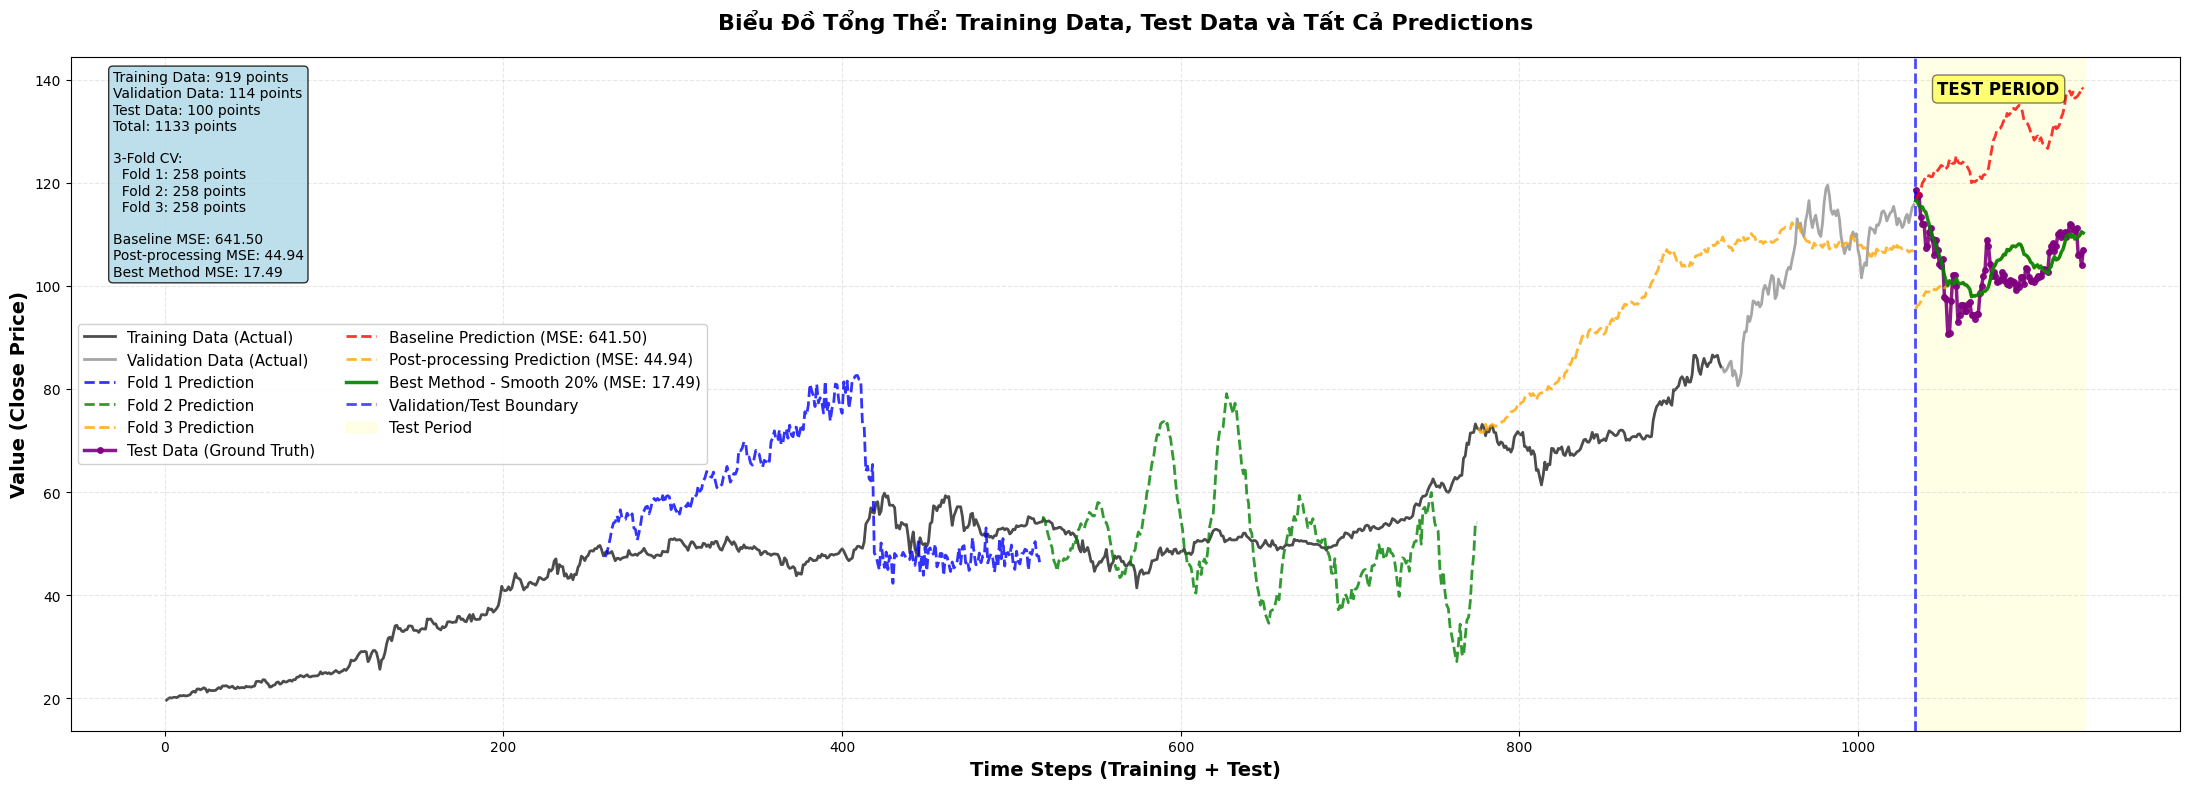

✓ Đã lưu biểu đồ zoom: complete_overview_zoom_test_period.png


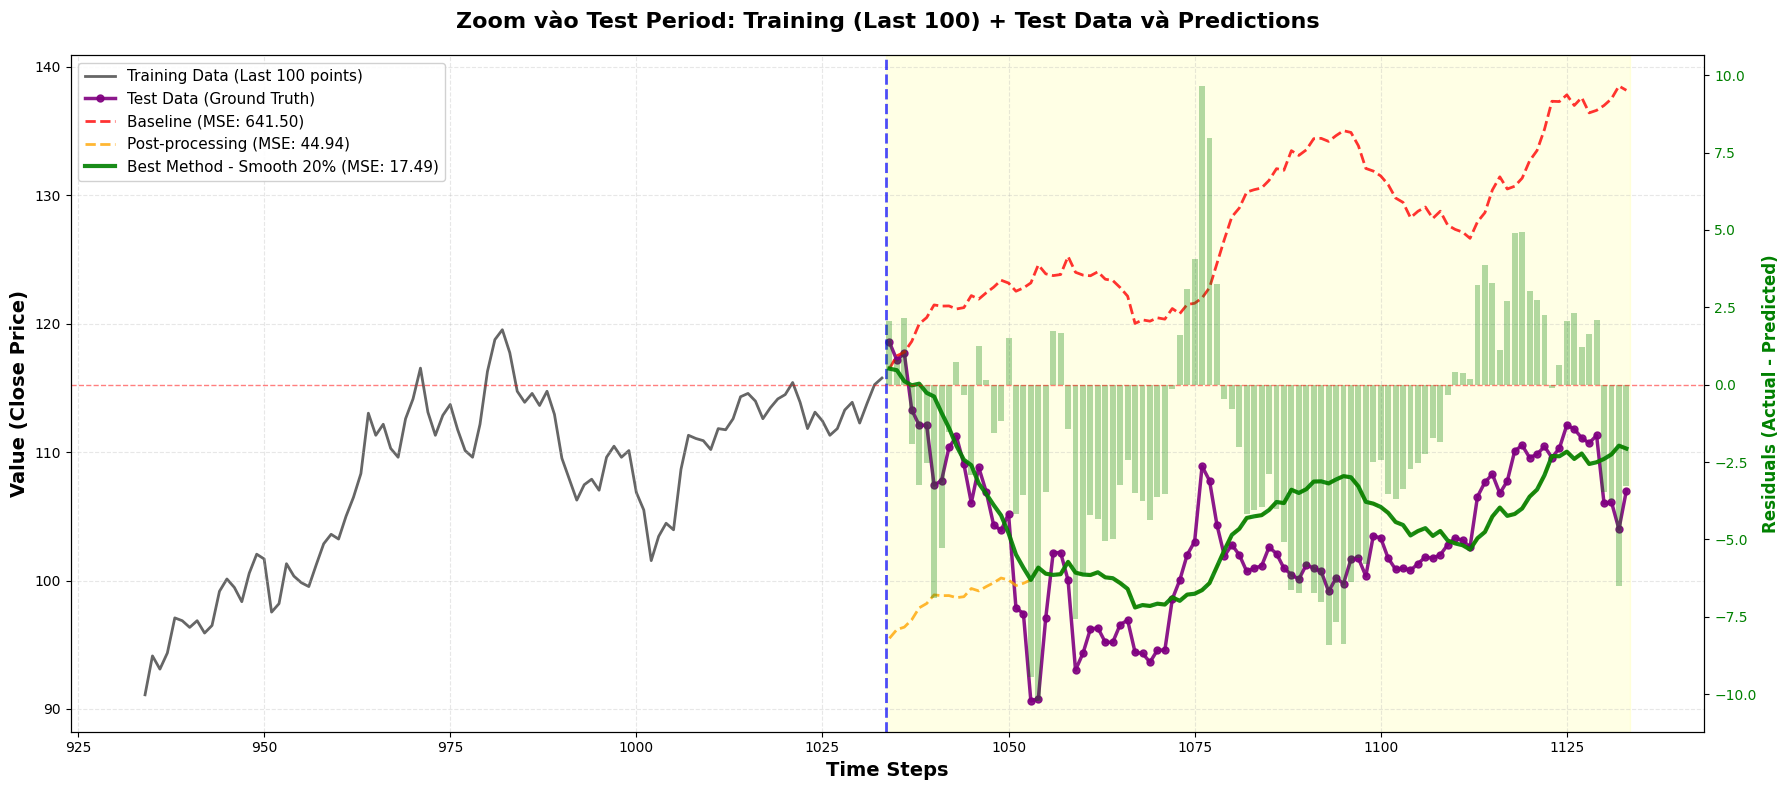

✓ Đã lưu biểu đồ residuals: complete_overview_residuals_analysis.png


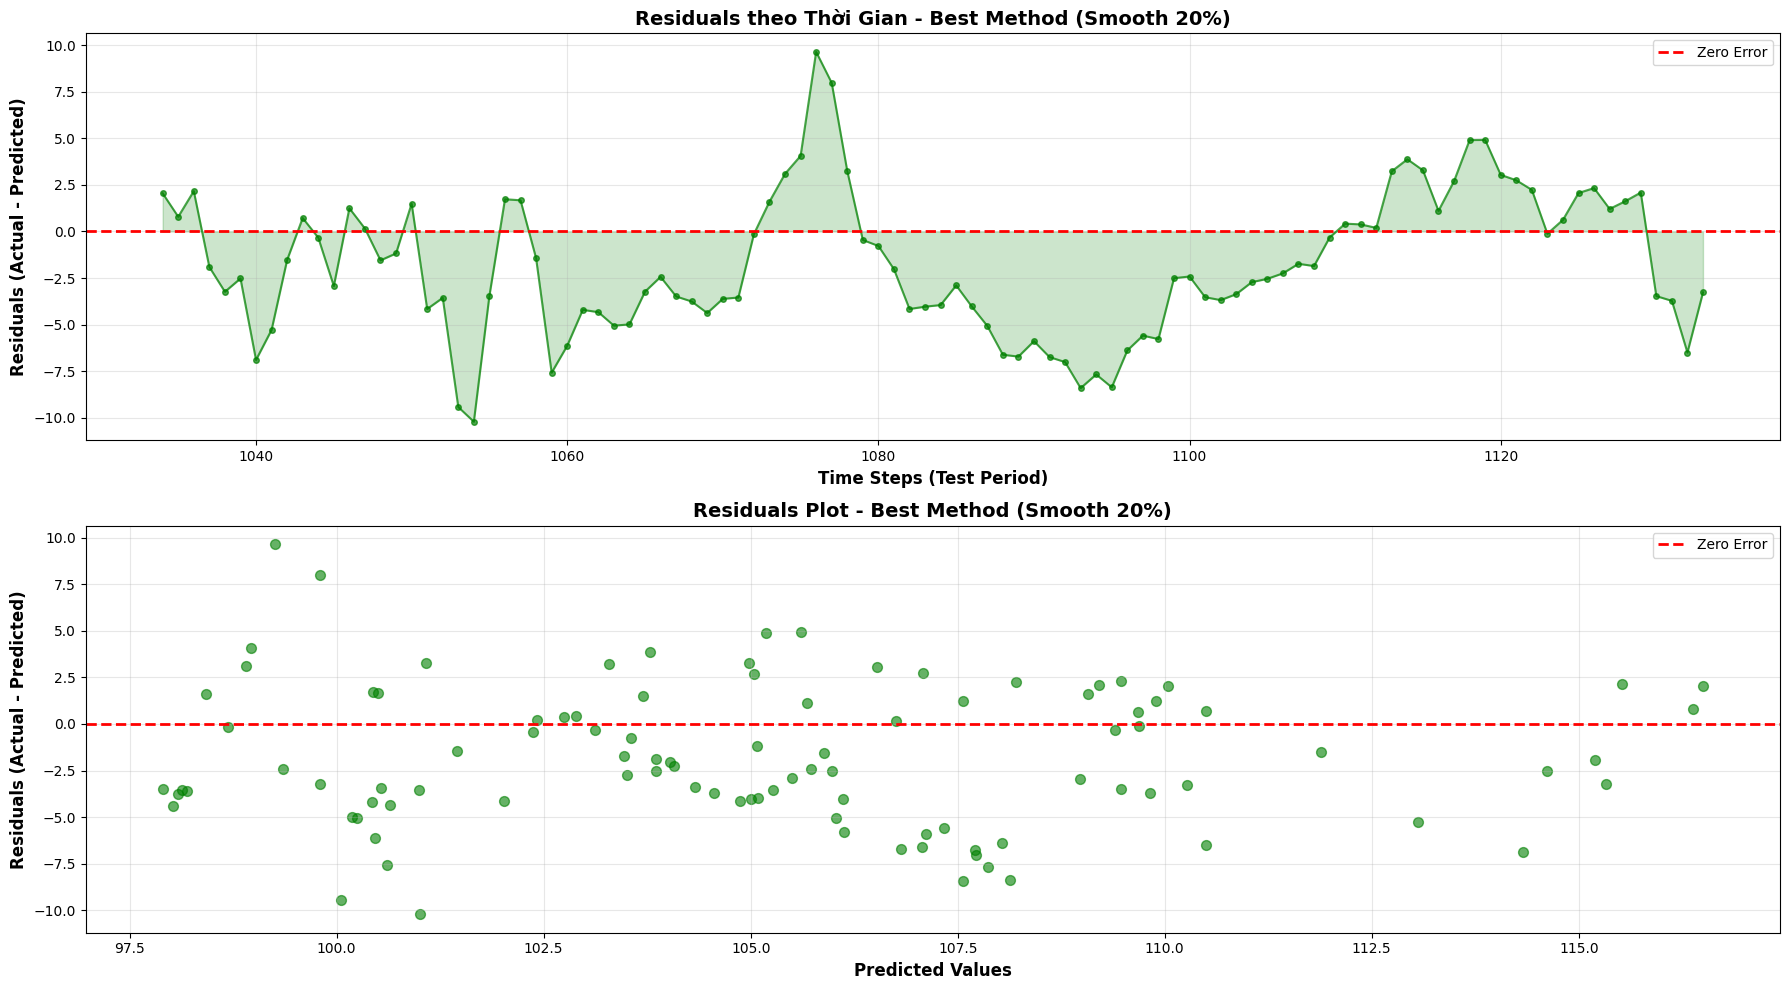


📊 TỔNG KẾT BIỂU ĐỒ:
   - Training data ban đầu: 919 điểm
   - Validation data ban đầu: 114 điểm
   - Test data: 100 điểm
   - 3-Fold Validation Predictions:
     * Fold 1: 258 điểm
     * Fold 2: 258 điểm
     * Fold 3: 258 điểm
   - Baseline MSE: 641.4994
   - Post-processing MSE: 44.9403
   - Best Method MSE: 17.4927
   - Improvement: +97.27%

✅ Hoàn thành tạo biểu đồ tổng thể!


In [ ]:
print("="*70)
print("📊 BIỂU ĐỒ TỔNG THỂ: TRAINING + TEST DATA VÀ TẤT CẢ PREDICTIONS")
print("="*70)

# Lấy training data ban đầu và validation data ban đầu
train_values = train_nf['y'].values
val_values = val_nf['y'].values
full_train_values = train_nf_full['y'].values

n_train_only = len(train_values)  # Training data ban đầu
n_val_only = len(val_values)      # Validation data ban đầu
n_train_full = len(full_train_values)  # Training + Validation (full)

# Lấy test data (ground truth)
n_test = len(y_true)

# Tính toán vị trí trong biểu đồ
# Training data ban đầu: từ 1 đến n_train_only
# Validation data ban đầu: từ n_train_only + 1 đến n_train_full
# Test data: từ n_train_full + 1 đến n_train_full + n_test
x_train = np.arange(1, n_train_only + 1)
x_val = np.arange(n_train_only + 1, n_train_full + 1)
x_test = np.arange(n_train_full + 1, n_train_full + n_test + 1)

# Tạo figure lớn
fig, ax = plt.subplots(1, 1, figsize=(22, 8))

# Vẽ training data ban đầu
ax.plot(x_train, train_values, '-',
        label='Training Data (Actual)',
        linewidth=2, color='black', alpha=0.7, zorder=1)

# Vẽ validation data ban đầu
ax.plot(x_val, val_values, '-',
        label='Validation Data (Actual)',
        linewidth=2, color='gray', alpha=0.7, zorder=1)

# Vẽ 3-fold validation predictions tại đúng vị trí trong train_nf_full
colors_fold = ['blue', 'green', 'orange']
fold_names_plot = ['Fold 1 Prediction', 'Fold 2 Prediction', 'Fold 3 Prediction']
for fold_idx in range(len(fold_predictions)):
    if fold_idx < len(fold_indices):
        val_indices = fold_indices[fold_idx]
        # Vị trí trong biểu đồ: val_indices + 1 (vì x-axis bắt đầu từ 1)
        x_fold = val_indices + 1
        pred_fold = fold_predictions[fold_idx]
        # Đảm bảo số lượng predictions khớp với số lượng indices
        n_fold = min(len(pred_fold), len(x_fold))
        ax.plot(x_fold[:n_fold], pred_fold[:n_fold], '--',
                label=fold_names_plot[fold_idx],
                linewidth=2, color=colors_fold[fold_idx], alpha=0.8, zorder=2)

# Vẽ test data (ground truth)
ax.plot(x_test, y_true, 'o-',
        label='Test Data (Ground Truth)',
        linewidth=2.5, markersize=4, color='purple', alpha=0.9, zorder=2)

# Vẽ các predictions trên test data
ax.plot(x_test, pred_patchtst_baseline[:n_test], '--', 
        label=f'Baseline Prediction (MSE: {mse_baseline:.2f})', 
        linewidth=2, color='red', alpha=0.8, zorder=3)

ax.plot(x_test, pred_post[:n_test], '--', 
        label=f'Post-processing Prediction (MSE: {mse_post:.2f})', 
        linewidth=2, color='orange', alpha=0.8, zorder=3)

ax.plot(x_test, pred_smooth[:n_test], '-', 
        label=f'Best Method - Smooth 20% (MSE: {mse_smooth:.2f})', 
        linewidth=2.5, color='green', alpha=0.9, zorder=4)

# Vẽ đường phân cách giữa validation và test
ax.axvline(x=n_train_full + 0.5, color='blue', linestyle='--', linewidth=2, alpha=0.7,
          label='Validation/Test Boundary')

# Highlight vùng test
ax.axvspan(n_train_full + 0.5, n_train_full + n_test + 0.5, alpha=0.1, color='yellow',
          label='Test Period')

# Labels và title
ax.set_xlabel('Time Steps (Training + Test)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Close Price)', fontsize=14, fontweight='bold')
ax.set_title('Biểu Đồ Tổng Thể: Training Data, Test Data và Tất Cả Predictions', 
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

# Thêm text box với thông tin
info_text = f'Training Data: {n_train_only} points\n'
info_text += f'Validation Data: {n_val_only} points\n'
info_text += f'Test Data: {n_test} points\n'
info_text += f'Total: {n_train_full + n_test} points\n\n'
info_text += f'3-Fold CV:\n'
for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        info_text += f'  Fold {fold_idx+1}: {len(fold_predictions[fold_idx])} points\n'
info_text += f'\nBaseline MSE: {mse_baseline:.2f}\n'
info_text += f'Post-processing MSE: {mse_post:.2f}\n'
info_text += f'Best Method MSE: {mse_smooth:.2f}'

ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
       fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Thêm annotation cho test period
ax.text(n_train_full + n_test/2, ax.get_ylim()[1] * 0.95,
       'TEST PERIOD',
       fontsize=12, ha='center', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('complete_overview_training_test_predictions.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Đã lưu biểu đồ tổng thể: complete_overview_training_test_predictions.png")
plt.show()

# Tạo biểu đồ zoom vào test period để xem chi tiết
fig2, ax2 = plt.subplots(1, 1, figsize=(18, 8))

# Vẽ training data (phần cuối để có context)
context_train = 100  # Hiển thị 100 điểm cuối của training
x_train_context = np.arange(max(1, n_train_full - context_train + 1), n_train_full + 1)
y_train_context = full_train_values[-context_train:]

ax2.plot(x_train_context, y_train_context, '-', 
        label='Training Data (Last 100 points)', 
        linewidth=2, color='black', alpha=0.6, zorder=1)

# Vẽ test data
ax2.plot(x_test, y_true, 'o-', 
        label='Test Data (Ground Truth)', 
        linewidth=2.5, markersize=5, color='purple', alpha=0.9, zorder=2)

# Vẽ các predictions
ax2.plot(x_test, pred_patchtst_baseline[:n_test], '--', 
        label=f'Baseline (MSE: {mse_baseline:.2f})', 
        linewidth=2, color='red', alpha=0.8, zorder=3)

ax2.plot(x_test, pred_post[:n_test], '--', 
        label=f'Post-processing (MSE: {mse_post:.2f})', 
        linewidth=2, color='orange', alpha=0.8, zorder=3)

ax2.plot(x_test, pred_smooth[:n_test], '-', 
        label=f'Best Method - Smooth 20% (MSE: {mse_smooth:.2f})', 
        linewidth=3, color='green', alpha=0.9, zorder=4)

# Vẽ đường phân cách
ax2.axvline(x=n_train_full + 0.5, color='blue', linestyle='--', linewidth=2, alpha=0.7)

# Highlight vùng test
ax2.axvspan(n_train_full + 0.5, n_train_full + n_test + 0.5, alpha=0.1, color='yellow')

# Labels và title
ax2.set_xlabel('Time Steps', fontsize=14, fontweight='bold')
ax2.set_ylabel('Value (Close Price)', fontsize=14, fontweight='bold')
ax2.set_title('Zoom vào Test Period: Training (Last 100) + Test Data và Predictions', 
            fontsize=16, fontweight='bold', pad=20)
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')

# Tính và hiển thị residuals cho best method
residuals_best = y_true - pred_smooth[:n_test]
ax2_twin = ax2.twinx()
ax2_twin.bar(x_test, residuals_best, alpha=0.3, color='green', width=0.8, label='Residuals (Best Method)')
ax2_twin.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2_twin.set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold', color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')

plt.tight_layout()
plt.savefig('complete_overview_zoom_test_period.png', dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ zoom: complete_overview_zoom_test_period.png")
plt.show()

# Tạo biểu đồ so sánh residuals
fig3, axes3 = plt.subplots(2, 1, figsize=(18, 10))

# Subplot 1: Residuals theo thời gian
axes3[0].plot(x_test, residuals_best, 'o-', linewidth=1.5, markersize=4, color='green', alpha=0.7)
axes3[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes3[0].fill_between(x_test, residuals_best, 0, alpha=0.2, color='green')
axes3[0].set_xlabel('Time Steps (Test Period)', fontsize=12, fontweight='bold')
axes3[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes3[0].set_title('Residuals theo Thời Gian - Best Method (Smooth 20%)', 
                  fontsize=14, fontweight='bold')
axes3[0].legend(loc='best', fontsize=10)
axes3[0].grid(True, alpha=0.3)

# Subplot 2: Scatter plot residuals
axes3[1].scatter(pred_smooth[:n_test], residuals_best, alpha=0.6, s=50, color='green')
axes3[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes3[1].set_xlabel('Predicted Values', fontsize=12, fontweight='bold')
axes3[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes3[1].set_title('Residuals Plot - Best Method (Smooth 20%)', 
                  fontsize=14, fontweight='bold')
axes3[1].legend(loc='best', fontsize=10)
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('complete_overview_residuals_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Đã lưu biểu đồ residuals: complete_overview_residuals_analysis.png")
plt.show()

print(f"\n📊 TỔNG KẾT BIỂU ĐỒ:")
print(f"   - Training data ban đầu: {n_train_only} điểm")
print(f"   - Validation data ban đầu: {n_val_only} điểm")
print(f"   - Test data: {n_test} điểm")
print(f"   - 3-Fold Validation Predictions:")
for fold_idx in range(3):
    if fold_idx < len(fold_predictions):
        print(f"     * Fold {fold_idx+1}: {len(fold_predictions[fold_idx])} điểm")
print(f"   - Baseline MSE: {mse_baseline:.4f}")
print(f"   - Post-processing MSE: {mse_post:.4f}")
print(f"   - Best Method MSE: {mse_smooth:.4f}")
print(f"   - Improvement: {((mse_baseline - mse_smooth) / mse_baseline) * 100:+.2f}%")

print(f"\n✅ Hoàn thành tạo biểu đồ tổng thể!")
